### 1. Liiketoiminnan ymmärrys

#### Tavoite
- Tutkia miten uni- ja liikuntatottumukset vaikuttavat hyvinvointiin ja aktiivisuustasoon.

#### Keskeiset kysymykset
- Voiko unen määrällä ja tasolla ennustaa tulevien päivien aktiivisuustasoa taikka hyvinvointia?
- Onko eri käyttäjäryhmillä selkeitä eroja unirytmissä ja liikuntamäärissä?
- Mitkä tekijät vaikuttavat unen määrään ja tasoon?

#### Vaadittava data
- Uni (kesto, taso)
- Liikunta (päivittäiset askeleet, aktiivisuusminuutit, kulutetut kalorit)
- Mahdollisesti lisämuuttujat (syke, stressitaso, unihäiriöt)

#### Mahdolliset rajoitteet
- Datan puute (Unen tasot puuttuvat, joten joudumme käyttämään epäsuoria mittareita kuten sykettä, liikunnan vaikutusta uneen, unen kestoa ja sen säännöllisyyttä.
- Käyttäjien erilaiset elämäntyylit ja taustatekijät
- Älykellodatan mahdollinen epätarkkuus

#### Odotetut tulokset
- Käyttäjäryhmien (klusterien) löytäminen unirytmien ja aktiivisuustottumusten perusteella
- Ennustemalli, joka arvioi aktiivisuustason unen perusteella
- Ymmärrys siitä, miten uni vaikuttaa päivittäiseen hyvinvointiin


### 2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

#### Tietoa datasetistä

"Tämä aineisto on kerätty vastaajilta hajautetun kyselyn kautta Amazon Mechanical Turkin avulla ajanjaksolla 03.12.2016–05.12.2016. Kolmekymmentä kelpoisuusehdot täyttävää Fitbit-käyttäjää antoi suostumuksensa henkilökohtaisten aktiivisuusmittaridatojen lähettämiseen, mukaan lukien minuuttitasoiset tiedot fyysisestä aktiivisuudesta, sykkeestä ja unen seurannasta. Eri laitteiden ja käyttäjien yksilölliset seurantatavat ja mieltymykset aiheuttavat vaihtelua aineiston tuloksissa."


Lähde: https://www.kaggle.com/datasets/nurudeenabdulsalaam/fitbit-fitness-tracker-data/data

#### Yleiset muuttujat
1. Id: Käyttäjän yksilöivä tunniste
2. TotalSteps: Päivän aikana otetut askeleet
3. TotalDistance: Kuljettu matka kilometreissä
4. Calories: Arvio kulutetuista kaloreista
5. Sleep.Value: 1 = Sleep / 2 = restless / 3 = Awake

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

daily_activity = pd.read_csv('archive/dailyActivity_merged.csv')
sleep_data = pd.read_csv('archive/sleepDay_merged.csv')
weight_data = pd.read_csv('archive/weightLogInfo_merged.csv')
heartrate_data = pd.read_csv('archive/heartrate_seconds_merged.csv')

# Display the first few rows of each DataFrame to understand the structure
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [108]:

# Check for missing dates in sleep data
print(sleep_data['SleepDay'].isnull().sum())

# Check for missing dates in heartrate data
print(heartrate_data['Time'].isnull().sum())

# Check for missing values in weight data
print(weight_data.isnull().sum())

# Check for missing values in daily activity data
print(daily_activity.isnull().sum())

0
0
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64
0
0
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesD

In [109]:

daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [110]:
heartrate_data.head()

,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


In [111]:
sleep_data.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [112]:

weight_data.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


In [113]:
# Check if there are missing values in the merge columns
print("Rows with missing values in 'SleepDay':")
print(sleep_data[sleep_data['SleepDay'].isna()])

print("\nRows with missing values in 'Time':")
print(heartrate_data[heartrate_data['Time'].isna()])


Rows with missing values in 'SleepDay':
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: []

Rows with missing values in 'Time':
Empty DataFrame
Columns: [Id, Time, Value]
Index: []
Rows with missing values in 'SleepDay':
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: []

Rows with missing values in 'Time':
Empty DataFrame
Columns: [Id, Time, Value]
Index: []
Rows with missing values in 'SleepDay':
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: []

Rows with missing values in 'Time':
Empty DataFrame
Columns: [Id, Time, Value]
Index: []
Rows with missing values in 'SleepDay':
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: []

Rows with missing values in 'Time':
Empty DataFrame
Columns: [Id, Time, Value]
Index: []


In [114]:
print("Data Types in Daily Activity Data:")
print(daily_activity.dtypes, '\n')

print("Data Types in Sleep Data:")
print(sleep_data.dtypes, '\n')

print("Data Types in Weight Data:")
print(weight_data.dtypes, '\n')

print("Data Types in Heart Rate Data:")
print(heartrate_data.dtypes, '\n')

Data Types in Daily Activity Data:
Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object 

Data Types in Sleep Data:
Id                     int64
SleepDay              object
TotalSleepRecords      int64
TotalMinutesAsleep     int64
TotalTimeInBed         int64
dtype: object 

Data Types in Weight Data:
Id                  int64
Date               object
WeightKg          float64
WeightPounds      float64
Fat               float64
BMI               float64
IsManualReport       bool
LogId        

In [115]:
print("Summary Statistics for Daily Activity Data:")
print(daily_activity.describe(), '\n')

print("Summary Statistics for Sleep Data:")
print(sleep_data.describe(), '\n')

print("Summary Statistics for Weight Data:")
print(weight_data.describe(), '\n')

print("Summary Statistics for Heart Rate Data:")
print(heartrate_data.describe(), '\n')

Summary Statistics for Daily Activity Data:
                 Id    TotalSteps  TotalDistance  TrackerDistance  \
count  9.400000e+02    940.000000     940.000000       940.000000   
mean   4.855407e+09   7637.910638       5.489702         5.475351   
std    2.424805e+09   5087.150742       3.924606         3.907276   
min    1.503960e+09      0.000000       0.000000         0.000000   
25%    2.320127e+09   3789.750000       2.620000         2.620000   
50%    4.445115e+09   7405.500000       5.245000         5.245000   
75%    6.962181e+09  10727.000000       7.712500         7.710000   
max    8.877689e+09  36019.000000      28.030001        28.030001   

       LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
count                940.000000          940.000000                940.000000   
mean                   0.108171            1.502681                  0.567543   
std                    0.619897            2.658941                  0.883580   
min       

In [116]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Calories Distribution - Daily Activity')

Text(0.5, 1.0, 'Calories Distribution - Daily Activity')

Text(0.5, 1.0, 'Calories Distribution - Daily Activity')

Text(0.5, 1.0, 'Calories Distribution - Daily Activity')

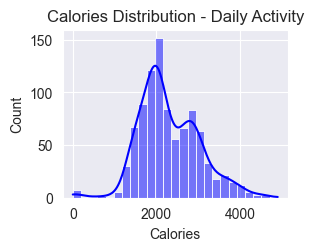

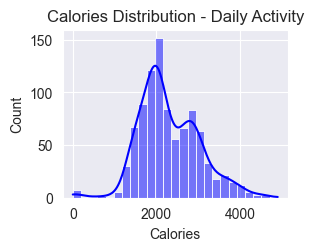

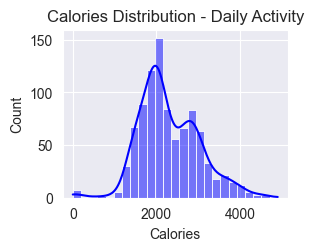

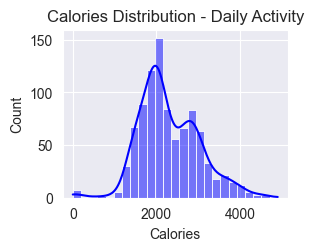

In [117]:
plt.subplot(2, 2, 1)
sns.histplot(daily_activity['Calories'], kde=True, color='blue')
plt.title('Calories Distribution - Daily Activity')

Text(0.5, 1.0, 'Total Minutes Asleep Distribution - Sleep Data')

Text(0.5, 1.0, 'Total Minutes Asleep Distribution - Sleep Data')

Text(0.5, 1.0, 'Total Minutes Asleep Distribution - Sleep Data')

Text(0.5, 1.0, 'Total Minutes Asleep Distribution - Sleep Data')

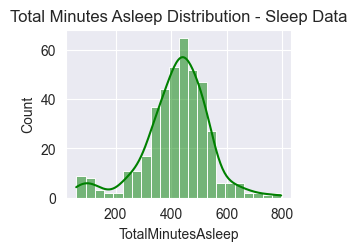

In [118]:
plt.subplot(2, 2, 2)
sns.histplot(sleep_data['TotalMinutesAsleep'], kde=True, color='green')
plt.title('Total Minutes Asleep Distribution - Sleep Data')

Text(0.5, 1.0, 'Weight Distribution - Weight Data')

Text(0.5, 1.0, 'Weight Distribution - Weight Data')

Text(0.5, 1.0, 'Weight Distribution - Weight Data')

Text(0.5, 1.0, 'Weight Distribution - Weight Data')

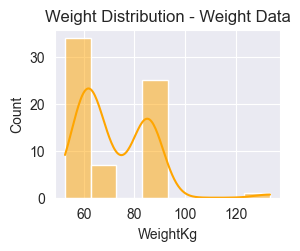

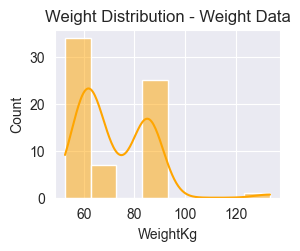

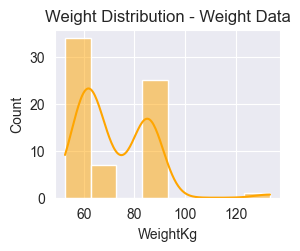

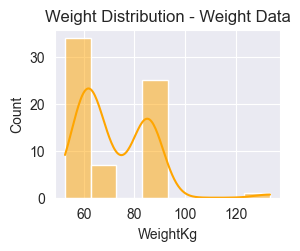

In [119]:
plt.subplot(2, 2, 3)
sns.histplot(weight_data['WeightKg'], kde=True, color='orange')
plt.title('Weight Distribution - Weight Data')

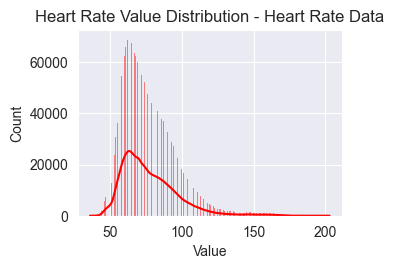

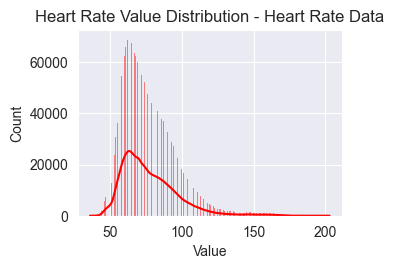

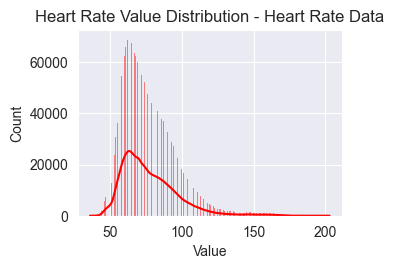

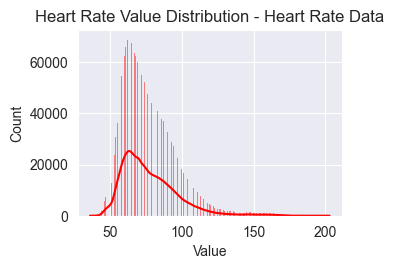

In [120]:
plt.subplot(2, 2, 4)
sns.histplot(heartrate_data['Value'], kde=True, color='red')
plt.title('Heart Rate Value Distribution - Heart Rate Data')

plt.tight_layout()
plt.show()

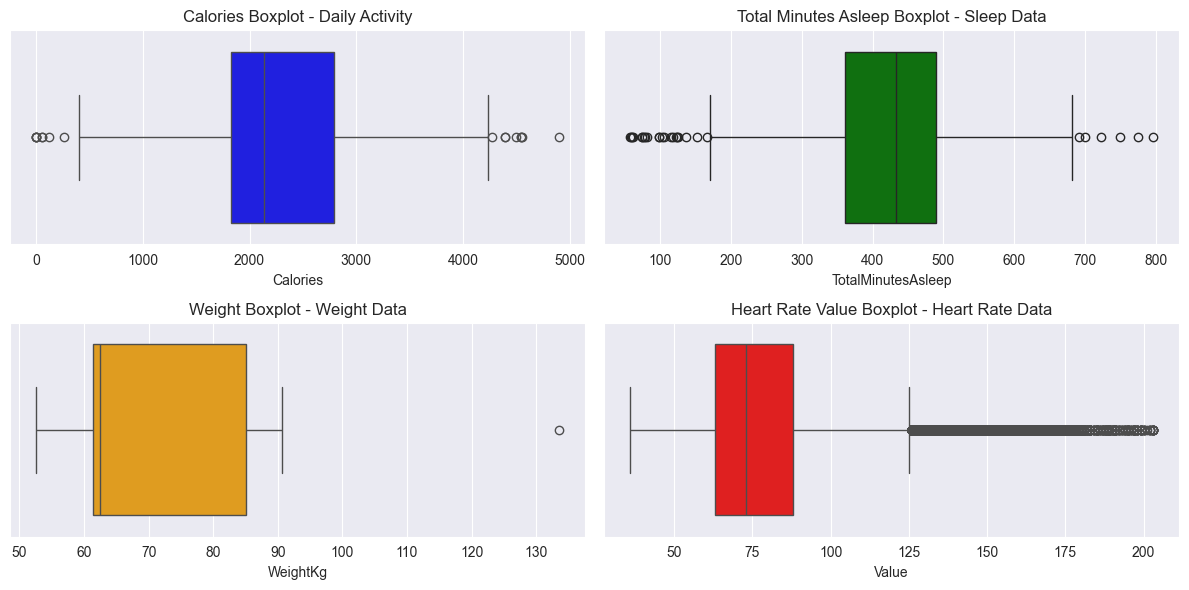

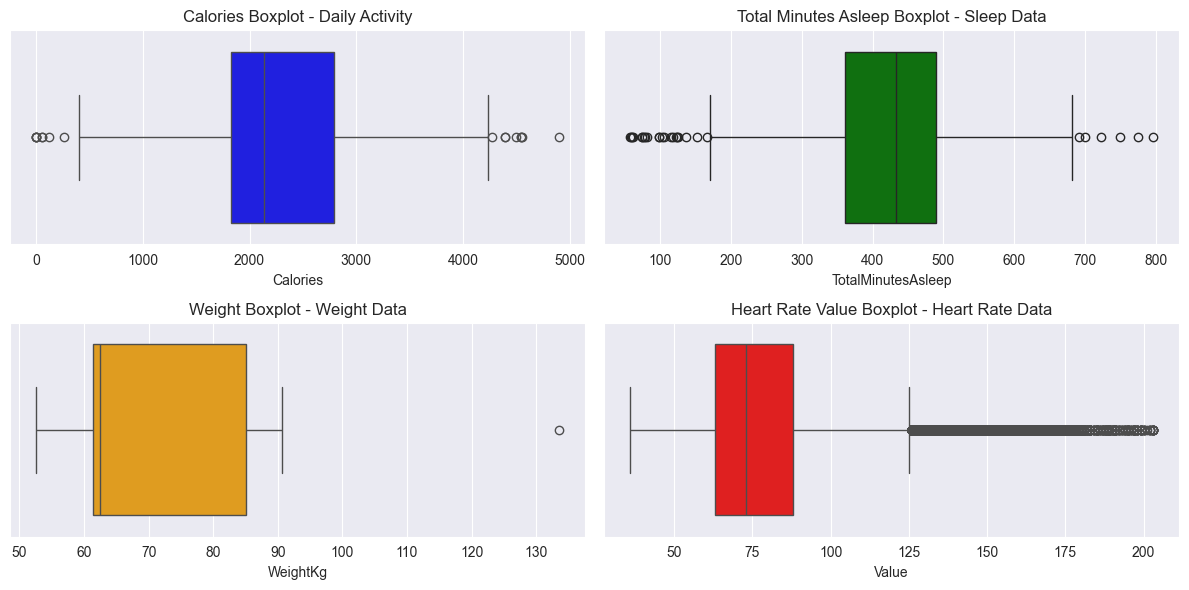

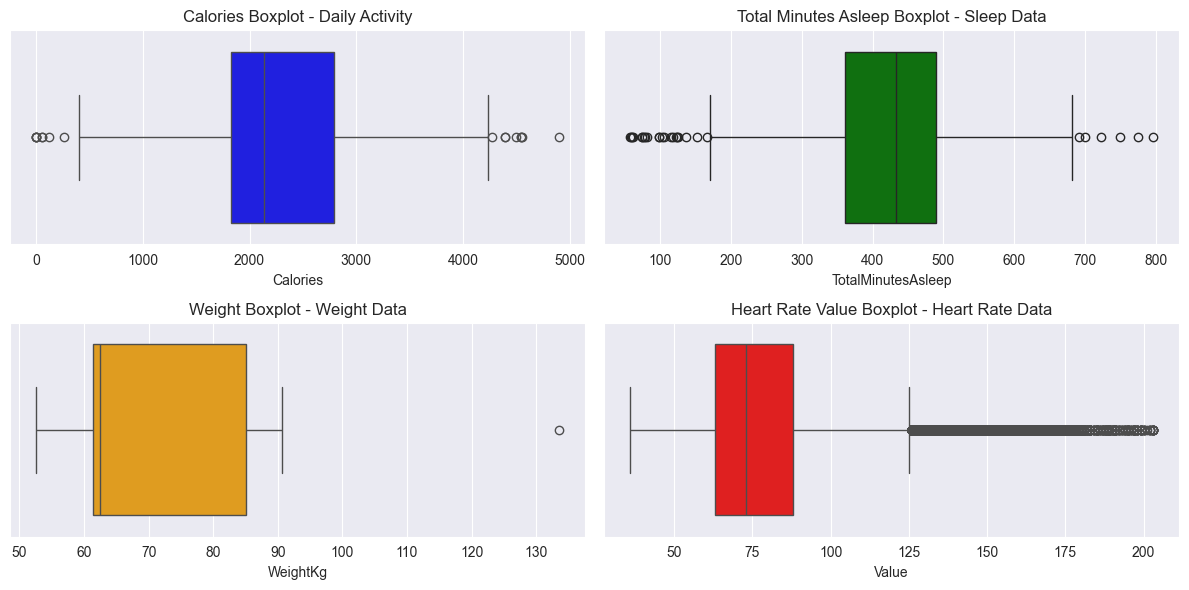

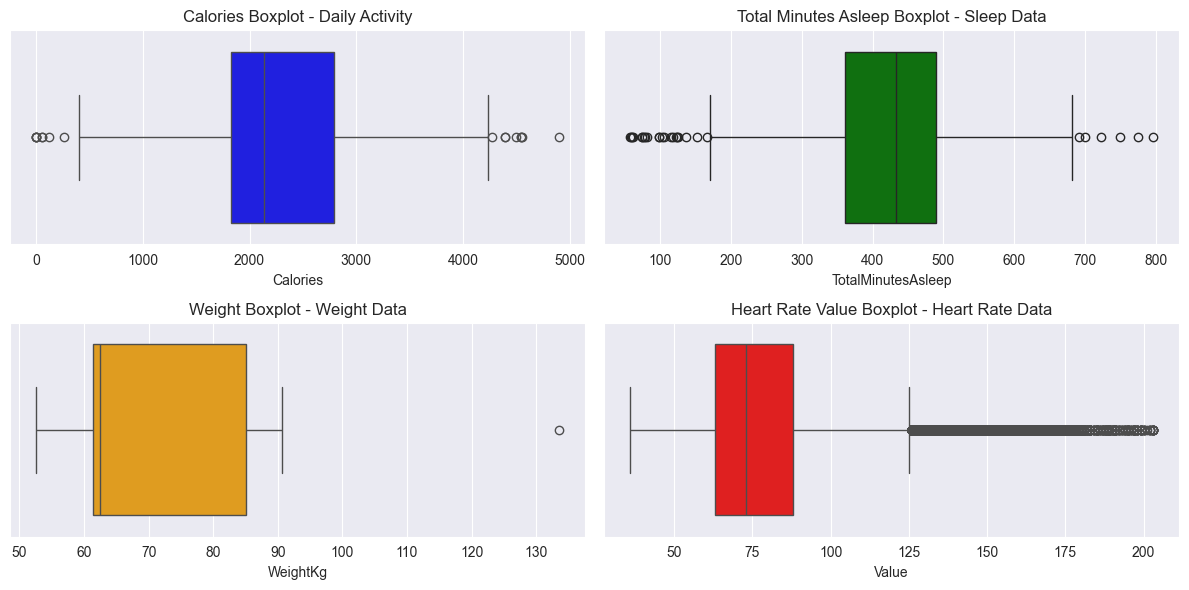

In [121]:

# Step 5: Check for outliers using boxplots
plt.figure(figsize=(12, 6))

# Boxplot for Daily Activity Calories
plt.subplot(2, 2, 1)
sns.boxplot(x=daily_activity['Calories'], color='blue')
plt.title('Calories Boxplot - Daily Activity')

# Boxplot for Sleep TotalMinutesAsleep
plt.subplot(2, 2, 2)
sns.boxplot(x=sleep_data['TotalMinutesAsleep'], color='green')
plt.title('Total Minutes Asleep Boxplot - Sleep Data')

# Boxplot for Weight
plt.subplot(2, 2, 3)
sns.boxplot(x=weight_data['WeightKg'], color='orange')
plt.title('Weight Boxplot - Weight Data')

# Boxplot for Heart Rate Value
plt.subplot(2, 2, 4)
sns.boxplot(x=heartrate_data['Value'], color='red')
plt.title('Heart Rate Value Boxplot - Heart Rate Data')

plt.tight_layout()
plt.show()

In [122]:

print("Check for Negative Values in Daily Activity Data:")
print(daily_activity[daily_activity['Calories'] < 0], '\n')

Check for Negative Values in Daily Activity Data:
Empty DataFrame
Columns: [Id, ActivityDate, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDistance, VeryActiveDistance, ModeratelyActiveDistance, LightActiveDistance, SedentaryActiveDistance, VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, SedentaryMinutes, Calories]
Index: [] 

Check for Negative Values in Daily Activity Data:
Empty DataFrame
Columns: [Id, ActivityDate, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDistance, VeryActiveDistance, ModeratelyActiveDistance, LightActiveDistance, SedentaryActiveDistance, VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, SedentaryMinutes, Calories]
Index: [] 

Check for Negative Values in Daily Activity Data:
Empty DataFrame
Columns: [Id, ActivityDate, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDistance, VeryActiveDistance, ModeratelyActiveDistance, LightActiveDistance, SedentaryActiveDistance, VeryActiveMinutes, FairlyAct

In [123]:

print("Check for Negative Values in Sleep Data:")
print(sleep_data[sleep_data['TotalMinutesAsleep'] < 0], '\n')

Check for Negative Values in Sleep Data:
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: [] 

Check for Negative Values in Sleep Data:
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: [] 

Check for Negative Values in Sleep Data:
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: [] 

Check for Negative Values in Sleep Data:
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: [] 



In [124]:

print("Check for Negative or Unrealistic Weight in Weight Data:")
print(weight_data[weight_data['WeightKg'] < 0], '\n')

Check for Negative or Unrealistic Weight in Weight Data:
Empty DataFrame
Columns: [Id, Date, WeightKg, WeightPounds, Fat, BMI, IsManualReport, LogId]
Index: [] 

Check for Negative or Unrealistic Weight in Weight Data:
Empty DataFrame
Columns: [Id, Date, WeightKg, WeightPounds, Fat, BMI, IsManualReport, LogId]
Index: [] 

Check for Negative or Unrealistic Weight in Weight Data:
Empty DataFrame
Columns: [Id, Date, WeightKg, WeightPounds, Fat, BMI, IsManualReport, LogId]
Index: [] 

Check for Negative or Unrealistic Weight in Weight Data:
Empty DataFrame
Columns: [Id, Date, WeightKg, WeightPounds, Fat, BMI, IsManualReport, LogId]
Index: [] 



In [125]:

print("Check for Unrealistic Heart Rate Values in Heart Rate Data:")
print(heartrate_data[heartrate_data['Value'] < 0], '\n')

Check for Unrealistic Heart Rate Values in Heart Rate Data:
Empty DataFrame
Columns: [Id, Time, Value]
Index: [] 

Check for Unrealistic Heart Rate Values in Heart Rate Data:
Empty DataFrame
Columns: [Id, Time, Value]
Index: [] 

Check for Unrealistic Heart Rate Values in Heart Rate Data:
Empty DataFrame
Columns: [Id, Time, Value]
Index: [] 

Check for Unrealistic Heart Rate Values in Heart Rate Data:
Empty DataFrame
Columns: [Id, Time, Value]
Index: [] 



In [126]:
correlation_daily_activity = daily_activity.corr()
print("Correlation Matrix - Daily Activity Data:")
print(correlation_daily_activity, '\n')

ValueError: could not convert string to float: '4/12/2016'

ValueError: could not convert string to float: '4/12/2016'

ValueError: could not convert string to float: '4/12/2016'

ValueError: could not convert string to float: '4/12/2016'

In [ ]:
correlation_sleep_data = sleep_data.corr()
print("Correlation Matrix - Sleep Data:")
print(correlation_sleep_data, '\n')

In [ ]:
correlation_weight_data = weight_data.corr()
print("Correlation Matrix - Weight Data:")
print(correlation_weight_data, '\n')

In [ ]:
correlation_heartrate_data = heartrate_data.corr()
print("Correlation Matrix - Heart Rate Data:")
print(correlation_heartrate_data, '\n')

### 3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

In [162]:
## Sydänsyke verrattuna unenlaatuun miinustamalla kokoaika hereilläoloajasta kokoaika nukkumiseen

sleep_data['TimeDifference'] = sleep_data['TotalTimeInBed'] - sleep_data['TotalMinutesAsleep']

# Step 3: Group by 'Id' and calculate the average TotalMinutesAsleep, TotalTimeInBed, and TimeDifference for each Id
sleep_grouped = sleep_data.groupby('Id').agg(
    avg_total_minutes_asleep=('TotalMinutesAsleep', 'mean'),
    avg_total_time_in_bed=('TotalTimeInBed', 'mean'),
    avg_time_difference_in_bed_vs_asleep=('TimeDifference', 'mean')
).reset_index()

# Step 5: Group by 'Id' and calculate the average, low, and high heart rates for each Id
heartrate_grouped = heartrate_data.groupby('Id')['Value'].agg(['mean', 'min', 'max']).reset_index()

# Step 6: Merge the aggregated sleep data and heart rate data by 'Id'
merged_data = pd.merge(sleep_grouped, heartrate_grouped, on='Id', how='inner')

# Step 7: Rename columns for better clarity
merged_data.rename(columns={
    'mean': 'avg_heart_rate',
    'min': 'min_heart_rate',
    'max': 'max_heart_rate',
}, inplace=True)

# Step 8: Display the first few rows of the renamed merged data
merged_data.head()

,Id,avg_total_minutes_asleep,avg_total_time_in_bed,avg_time_difference_in_bed_vs_asleep,avg_heart_rate,min_heart_rate,max_heart_rate
0,2026352035,506.178571,537.642857,31.464286,93.776305,63,125
1,2347167796,446.800000,491.333333,44.533333,76.722792,49,195
2,4020332650,349.375000,379.750000,30.375000,82.300577,46,191
3,4388161847,403.125000,426.208333,23.083333,66.132998,39,180
4,4558609924,127.600000,140.000000,12.400000,81.673947,44,199


In [256]:

# Compute the correlation between sleep time efficiency (time difference) and heart rates
correlation = merged_data[['avg_time_difference_in_bed_vs_asleep', 'avg_heart_rate', 'min_heart_rate', 'max_heart_rate']].corr()

# Display the correlation matrix
print("Correlation between Sleep Efficiency and Heart Rates:")
print(correlation)


KeyError: "None of [Index(['avg_time_difference_in_bed_vs_asleep', 'avg_heart_rate',\n       'min_heart_rate', 'max_heart_rate'],\n      dtype='object')] are in the [columns]"

In [211]:

# Scatter plot between heart rate and TotalMinutesAsleep
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_data['Value'], y=merged_data['TotalMinutesAsleep'])
plt.title('Heart Rate vs Total Minutes Asleep')
plt.xlabel('Heart Rate')
plt.ylabel('Total Minutes Asleep')
plt.show()

KeyError: 'Value'

<Figure size 1000x600 with 0 Axes>

In [210]:

# Scatter plot between heart rate and TotalTimeInBed
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_data['Value'], y=merged_data['TotalTimeInBed'])
plt.title('Heart Rate vs Total Time in Bed')
plt.xlabel('Heart Rate')
plt.ylabel('Total Time in Bed')
plt.show()

KeyError: 'Value'

<Figure size 1000x600 with 0 Axes>

In [209]:

# Create a simple sleep quality indicator (sleep efficiency)
merged_data['SleepEfficiency'] = merged_data['TotalMinutesAsleep'] / merged_data['TotalTimeInBed']

# Plot Sleep Efficiency against Heart Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_data['Value'], y=merged_data['SleepEfficiency'])
plt.title('Heart Rate vs Sleep Efficiency')
plt.xlabel('Heart Rate')
plt.ylabel('Sleep Efficiency')
plt.show()

KeyError: 'Value'

<Figure size 1000x600 with 0 Axes>

In [ ]:


from scipy.stats import pearsonr

# Pearson correlation test between Heart Rate and TotalMinutesAsleep
corr_value, p_value = pearsonr(merged_data['Value'], merged_data['TotalMinutesAsleep'])
print(f"Pearson correlation: {corr_value}, p-value: {p_value}")

# Pearson correlation test between Heart Rate and Sleep Efficiency
corr_efficiency, p_value_efficiency = pearsonr(merged_data['Value'], merged_data['SleepEfficiency'])
print(f"Pearson correlation with Sleep Efficiency: {corr_efficiency}, p-value: {p_value_efficiency}")

In [78]:
from sklearn.preprocessing import StandardScaler

## Ismetin hommelit 
# Assuming your data is loaded into pandas DataFrames
# weight_data: CSV data with weight information
# sleep_data: CSV data with sleep information

# Merge data based on Id
merged_data = pd.merge(weight_data, sleep_data, on="Id")

# Standardize the Weight and Sleep data (excluding 'Id' and 'Date')
scaler = StandardScaler()
merged_data[['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed']] = scaler.fit_transform(
    merged_data[['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed']]
)

# Calculate the difference in time spent in bed and actual sleep
merged_data['TimeDifference'] = merged_data['TotalTimeInBed'] - merged_data['TotalMinutesAsleep']

# You can now perform correlation analysis, such as:
correlation_matrix = merged_data[['WeightKg', 'TotalMinutesAsleep', 'TimeDifference']].corr()

# Output the correlation matrix
print(correlation_matrix)
print('--------------------')
correlation, p_value = pearsonr(merged_data['WeightKg'], merged_data['TimeDifference'])
print(f"Correlation: {correlation}, p-value: {p_value}")


                    WeightKg  TotalMinutesAsleep  TimeDifference
WeightKg            1.000000           -0.025836        0.099106
TotalMinutesAsleep -0.025836            1.000000       -0.066643
TimeDifference      0.099106           -0.066643        1.000000
--------------------
Correlation: 0.09910590607728759, p-value: 0.0010630088314270527


In [127]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'merged_data' is your DataFrame with the original data
# Select the features you want to cluster
X = merged_data[['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed', 'TimeDifference']]

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Elbow method to determine the optimal number of clusters
inertia = []  # List to store inertia (sum of squared distances)
for k in range(1, 11):  # Try k values from 1 to 10
    model = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=100)
    model.fit(X_scaled)  # Fit the model using the scaled data
    inertia.append(model.inertia_)  # Store the inertia value for each k

# Plot the elbow method graph
plt.plot(range(1, 11), inertia)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Step 3: Fit KMeans with the optimal number of clusters (based on elbow method)
optimal_k = 4  # You can adjust this value based on the elbow method results
model = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++', n_init=100)
model.fit(X_scaled)  # Fit the model using the scaled data

# Step 4: Add the cluster labels to the DataFrame
merged_data['cluster'] = model.labels_

# Step 5: Get the centroids of the clusters
centroids = model.cluster_centers_

# Step 6: Create the plot for weight and sleep metrics
plt.figure(figsize=(10, 6))

# Scatter plot of the data points, colored by their cluster label
plt.scatter(merged_data['WeightKg'], merged_data['TotalMinutesAsleep'], c=merged_data['cluster'], cmap='viridis', marker='o', label='Data Points')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')

plt.xlabel('Weight (Kg)')
plt.ylabel('Total Minutes Asleep')
plt.title('KMeans Clustering of Weight and Sleep Metrics')
plt.legend()
plt.show()

# Step 7: Display the cluster centers (centroids)

KeyError: "None of [Index(['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed', 'TimeDifference'], dtype='object')] are in the [columns]"

KeyError: "None of [Index(['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed', 'TimeDifference'], dtype='object')] are in the [columns]"

KeyError: "None of [Index(['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed', 'TimeDifference'], dtype='object')] are in the [columns]"

KeyError: "None of [Index(['WeightKg', 'TotalMinutesAsleep', 'TotalTimeInBed', 'TimeDifference'], dtype='object')] are in the [columns]"

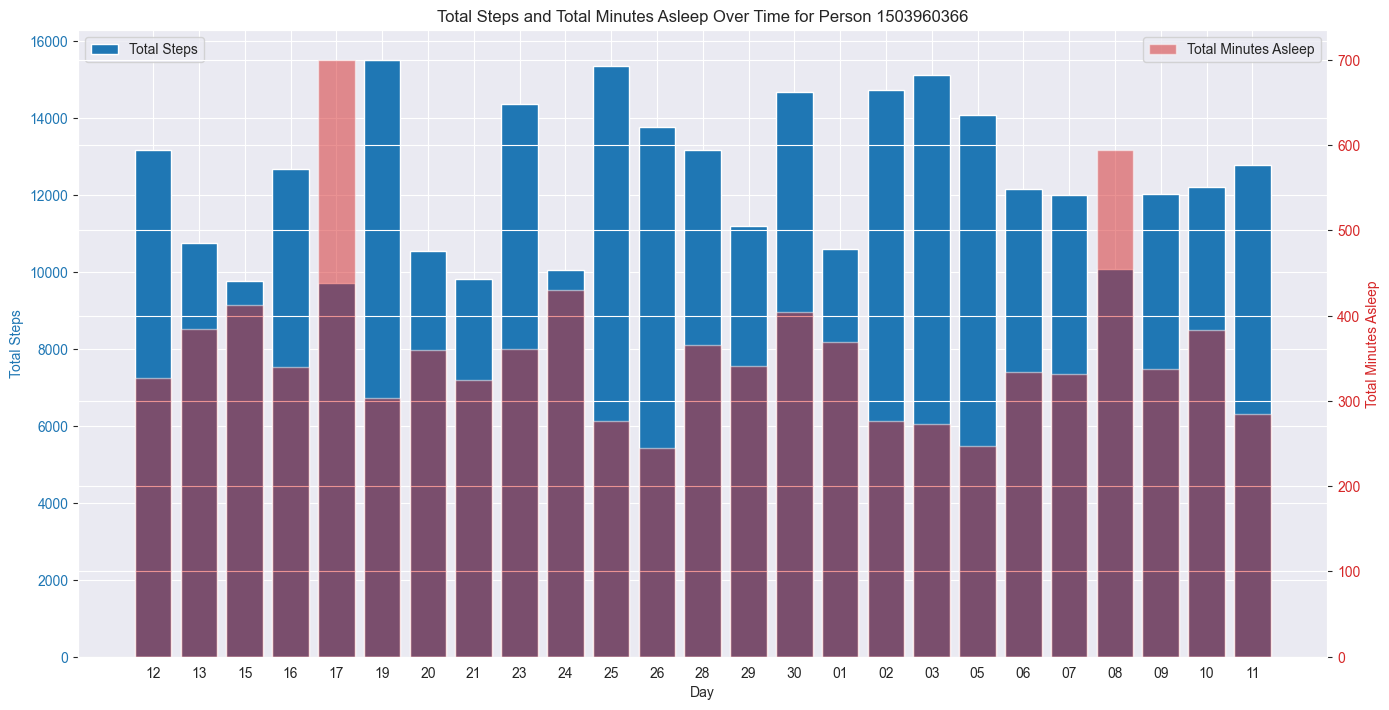

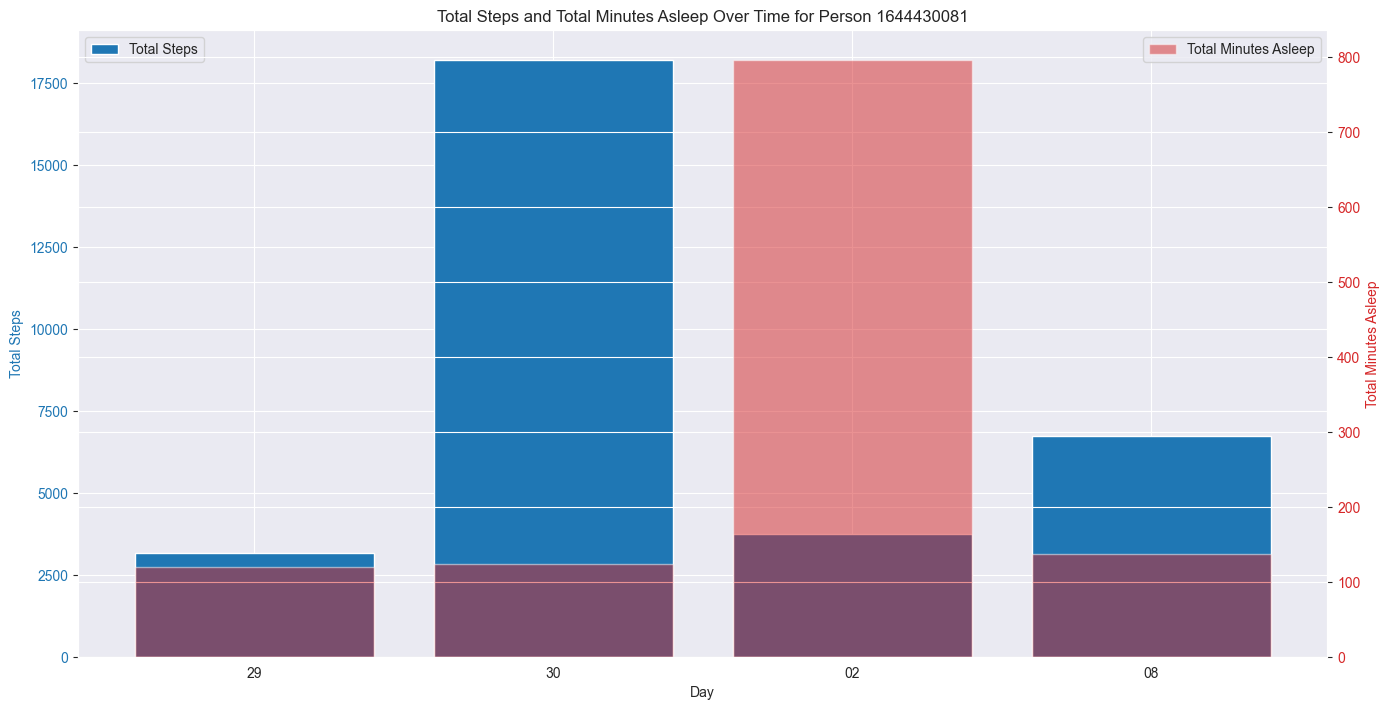

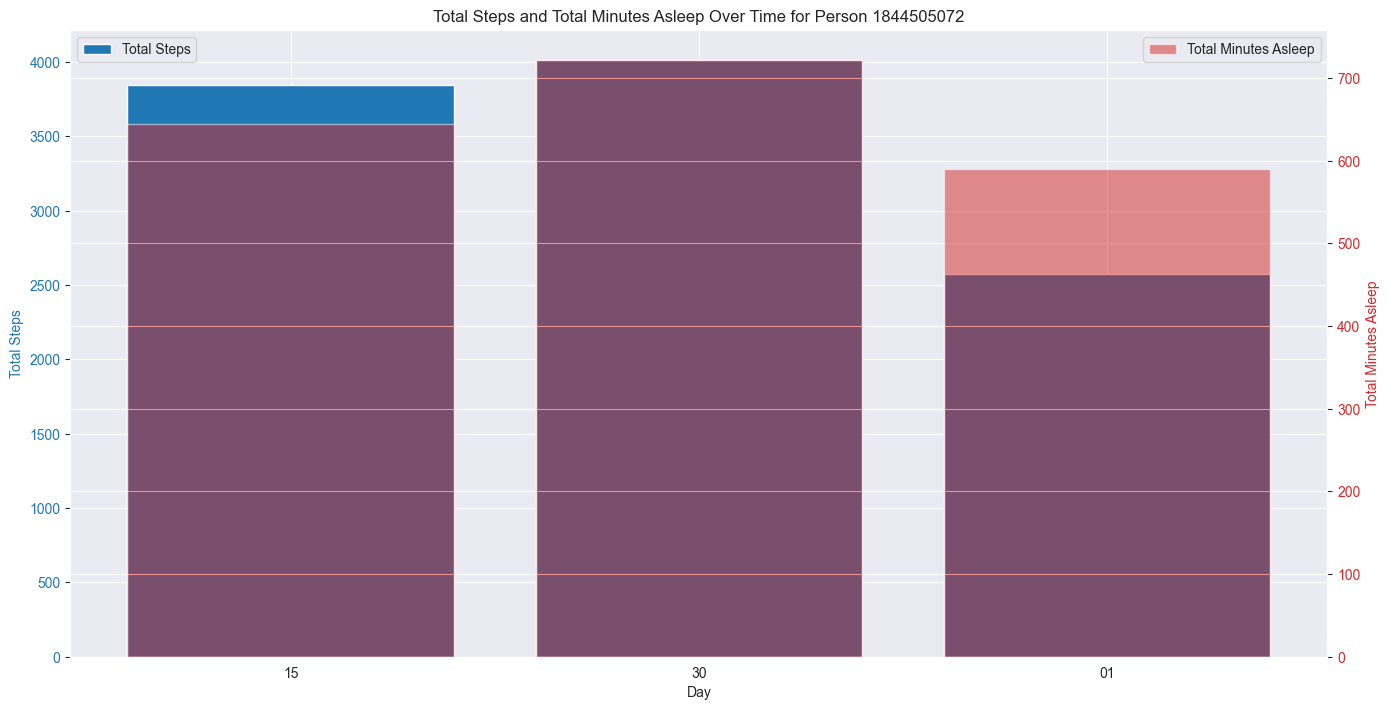

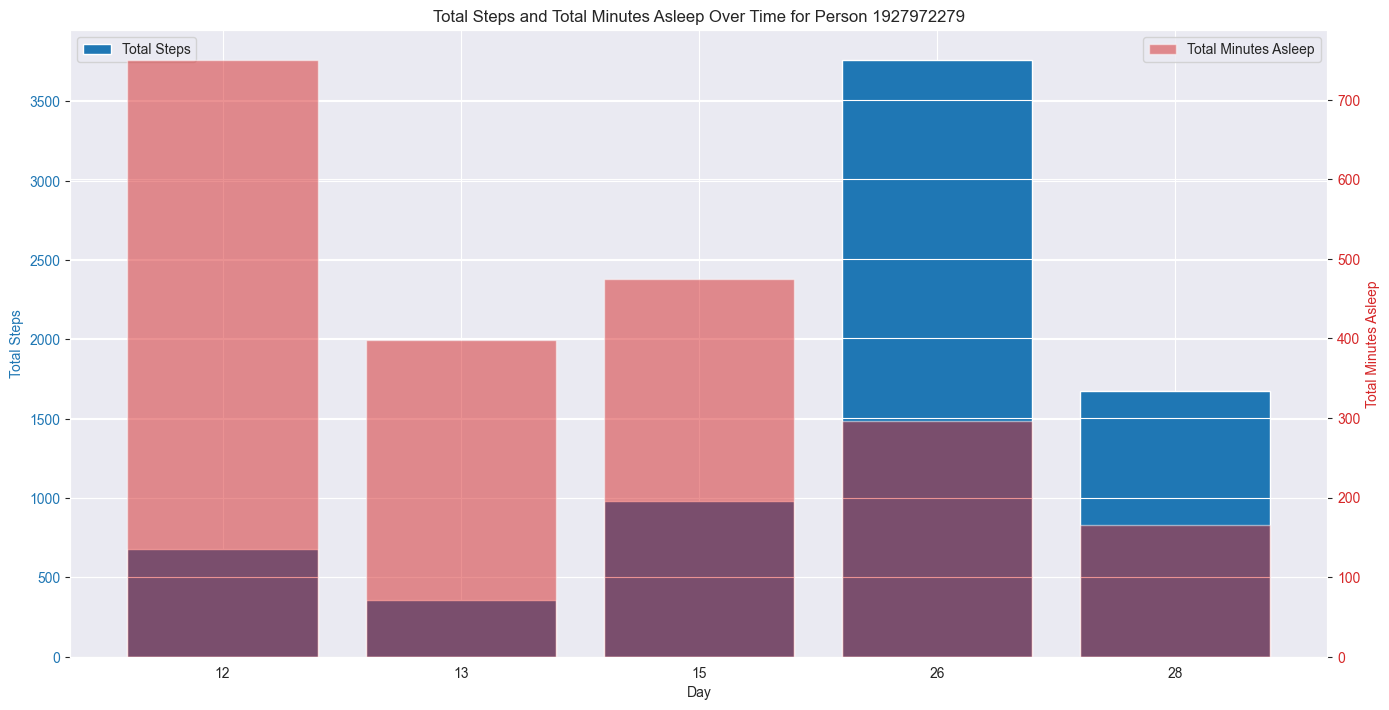

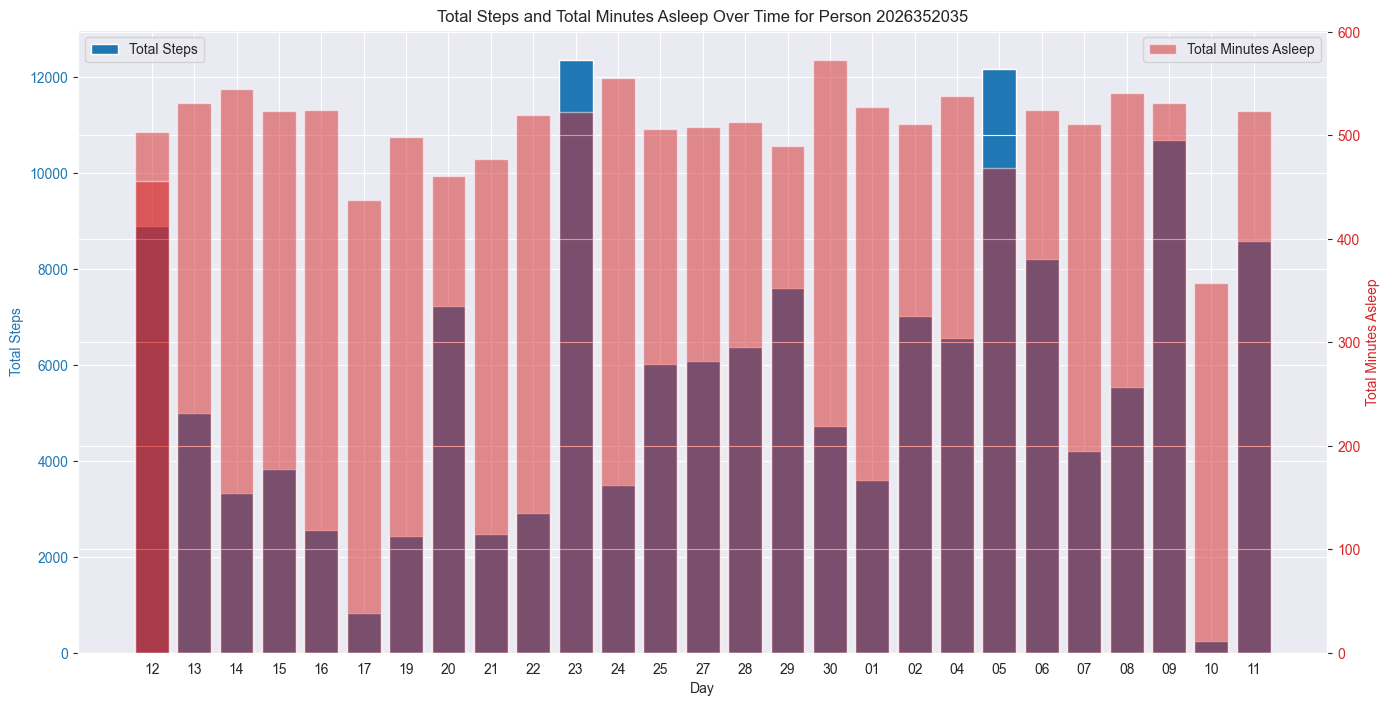

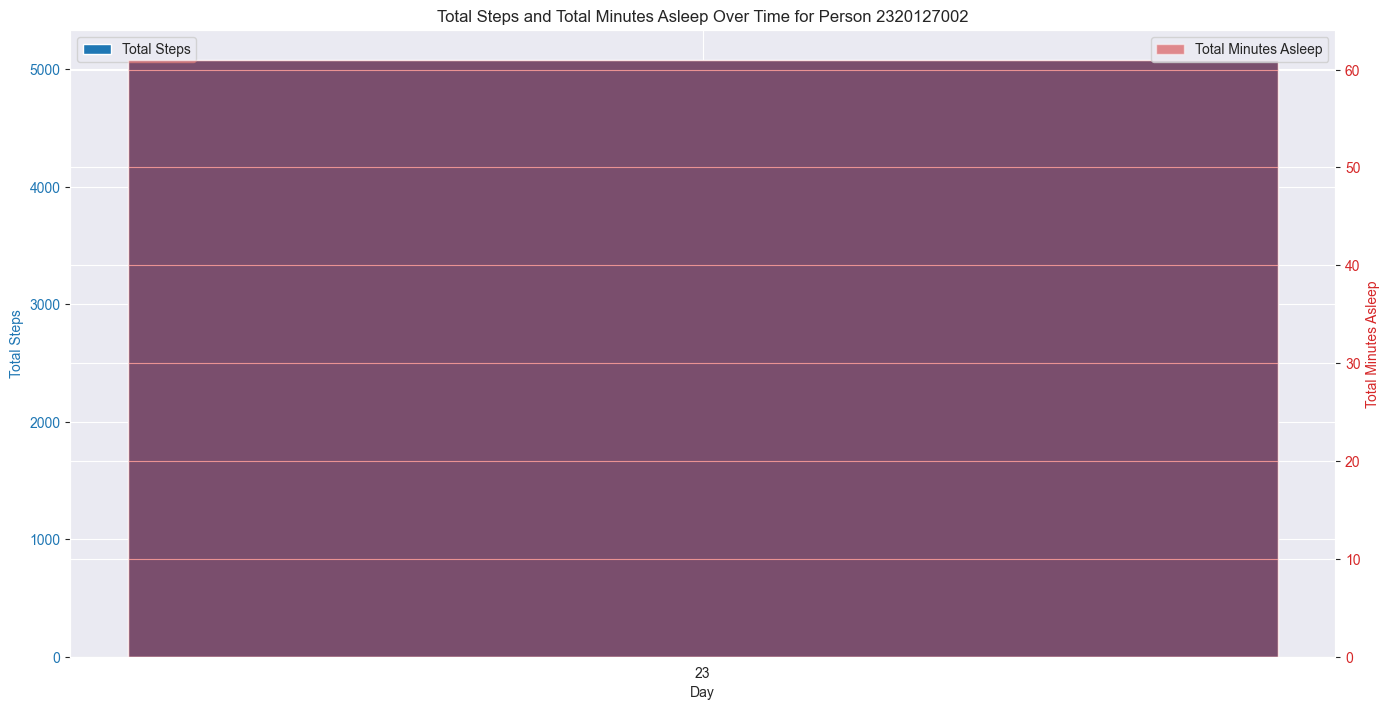

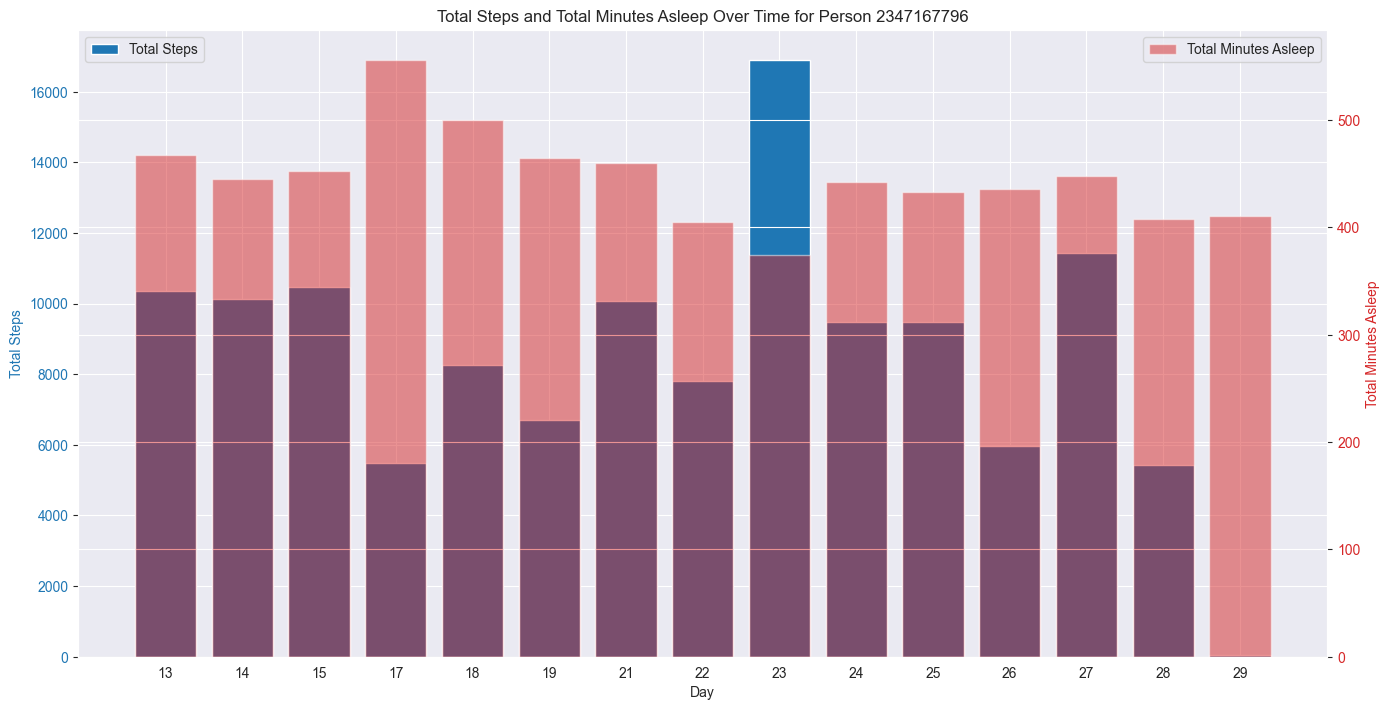

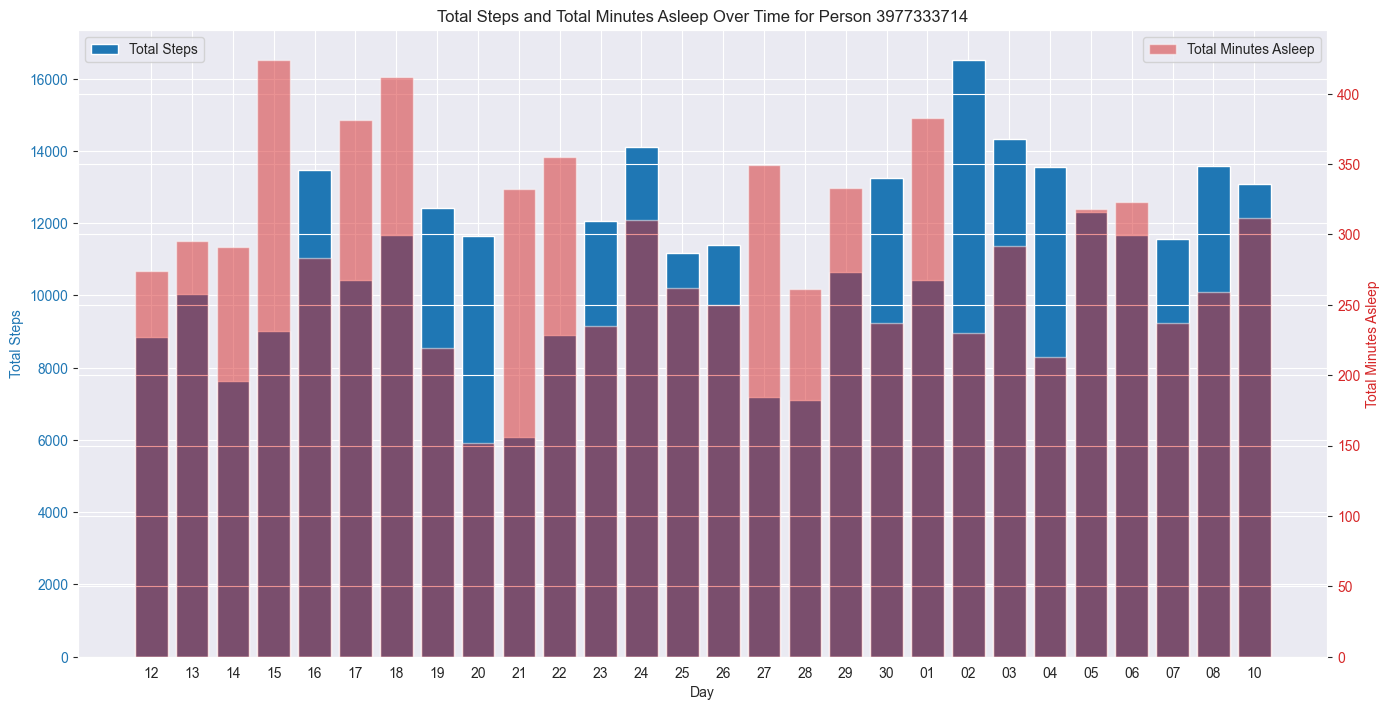

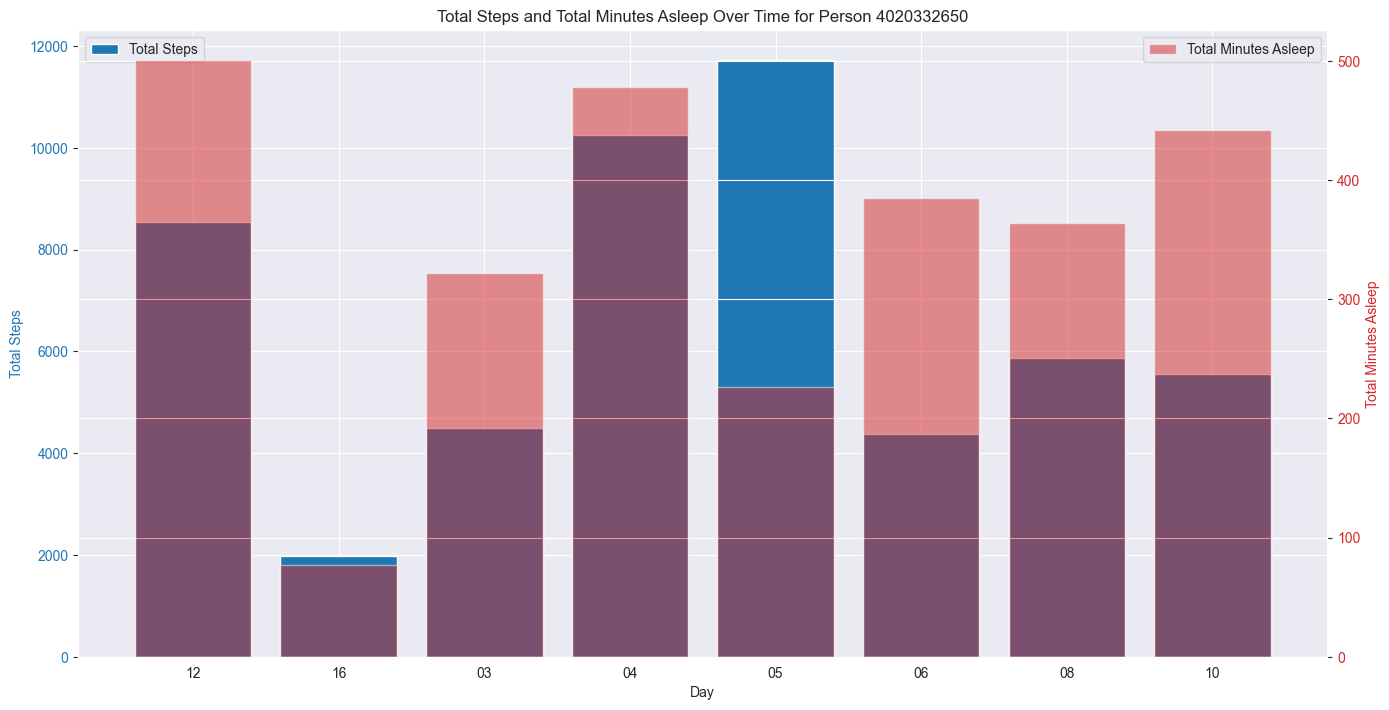

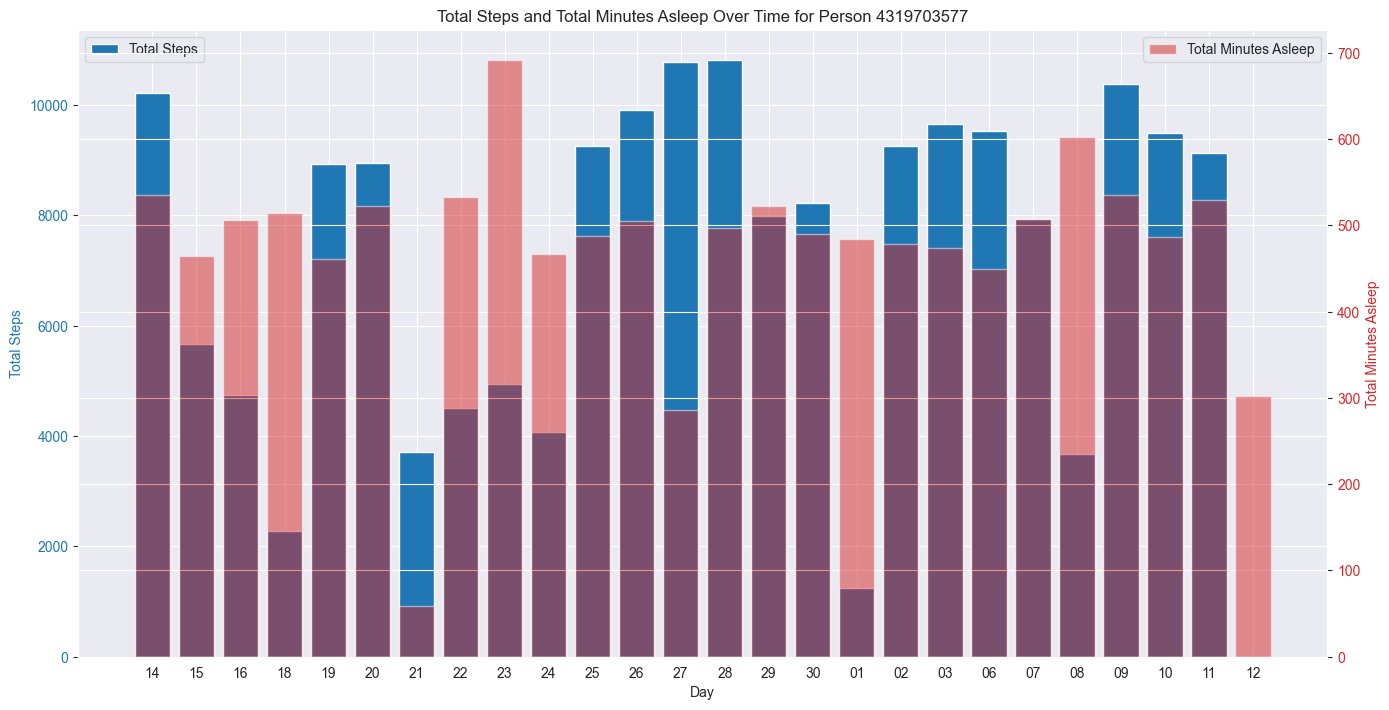

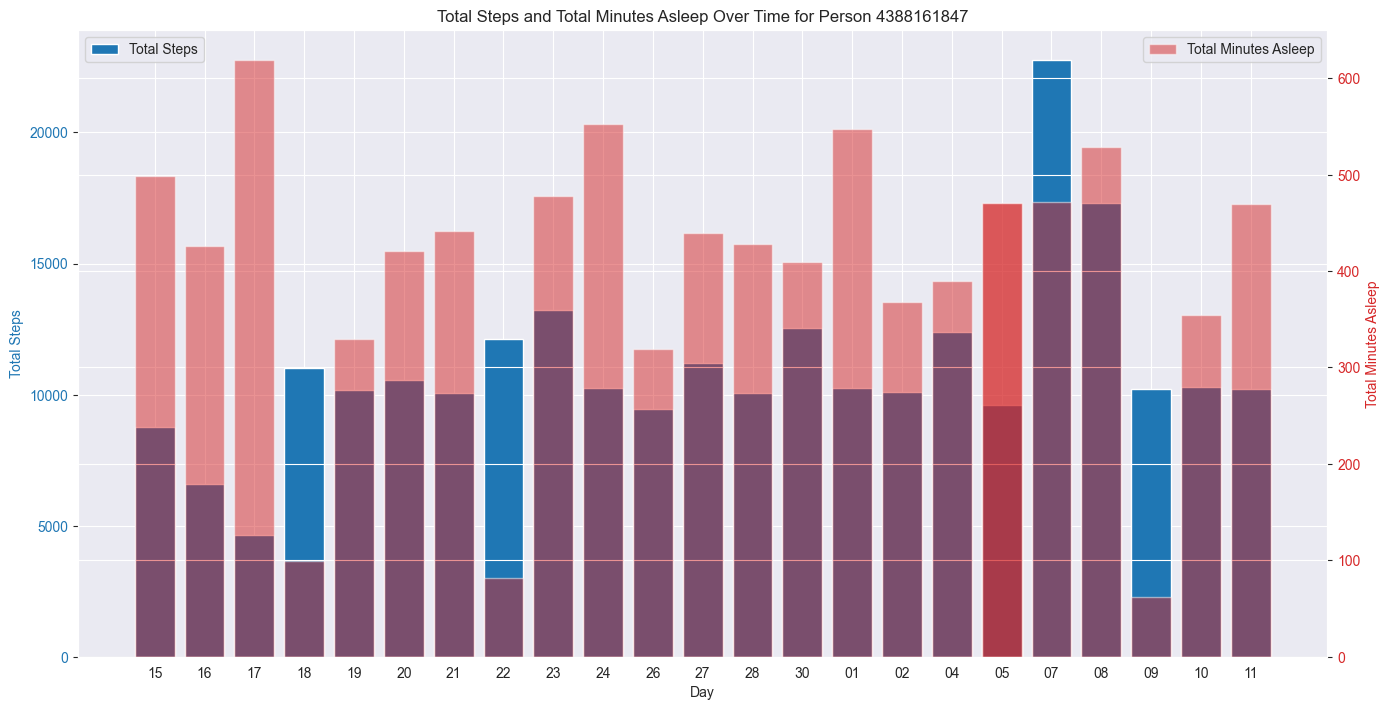

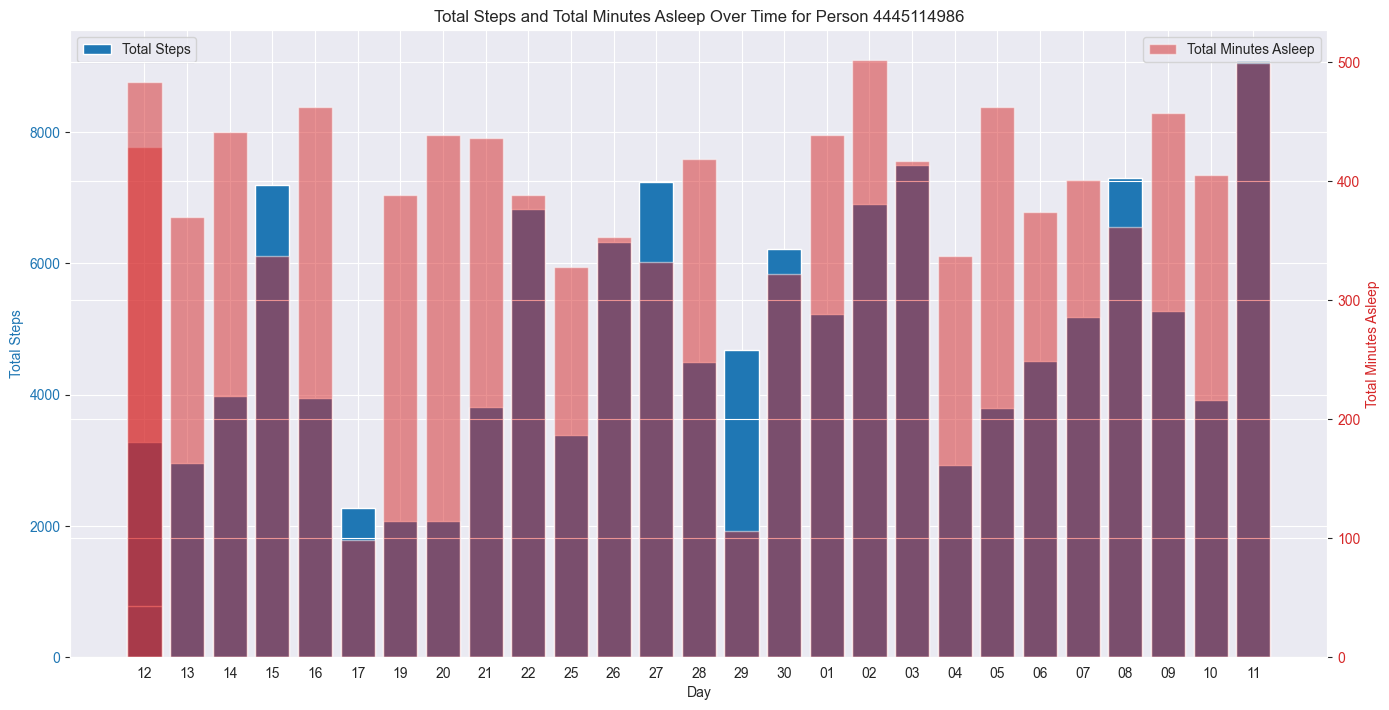

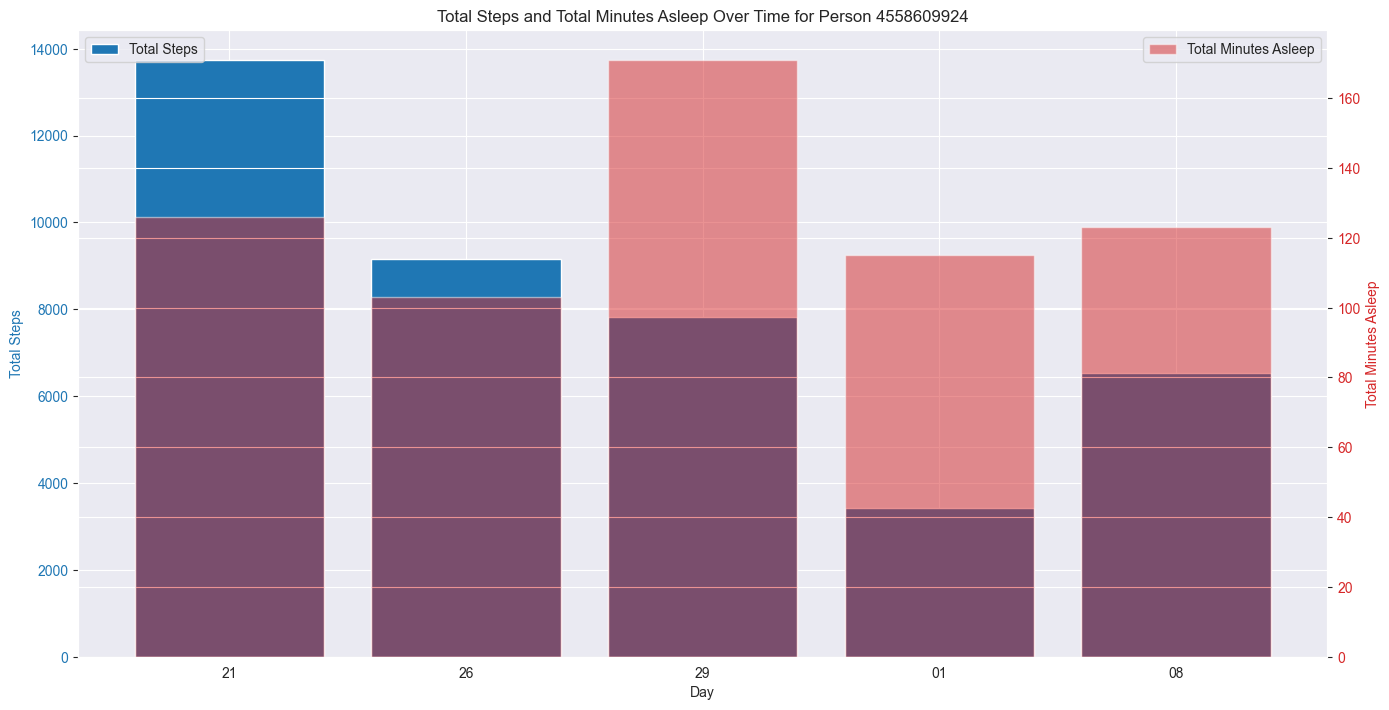

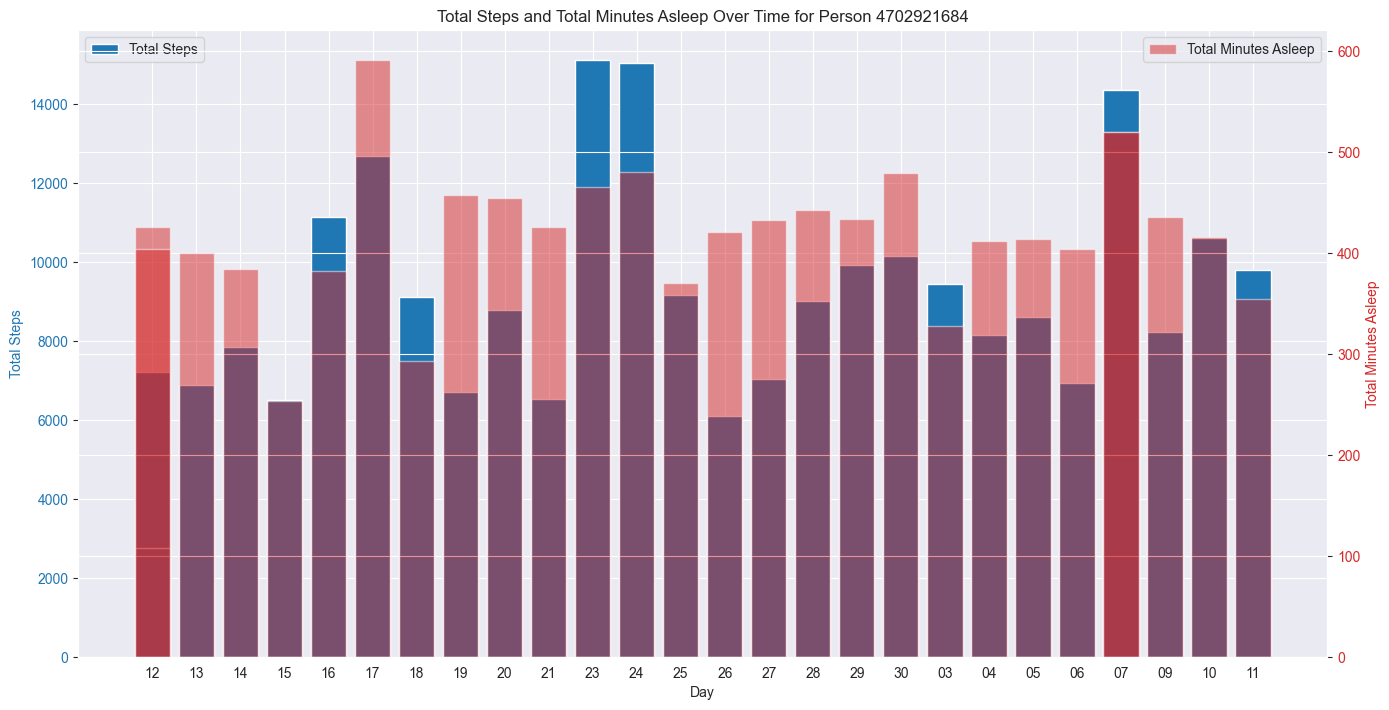

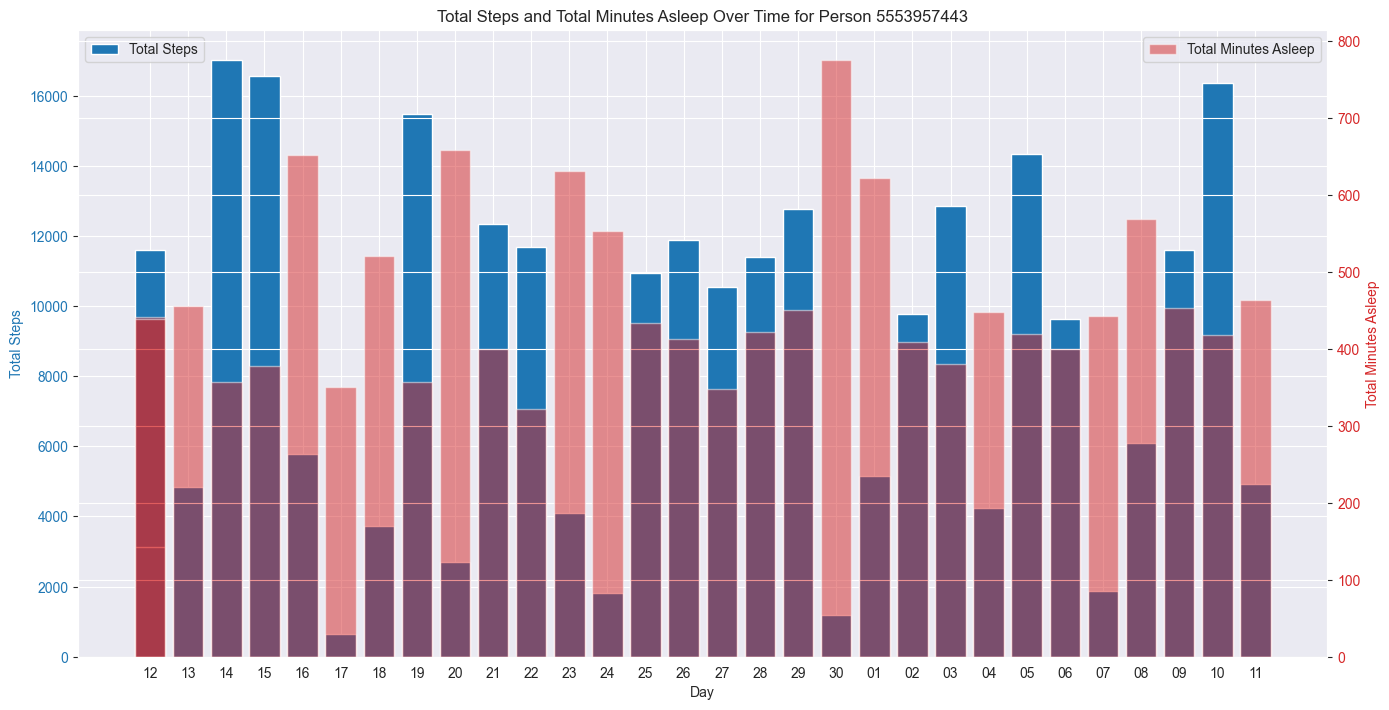

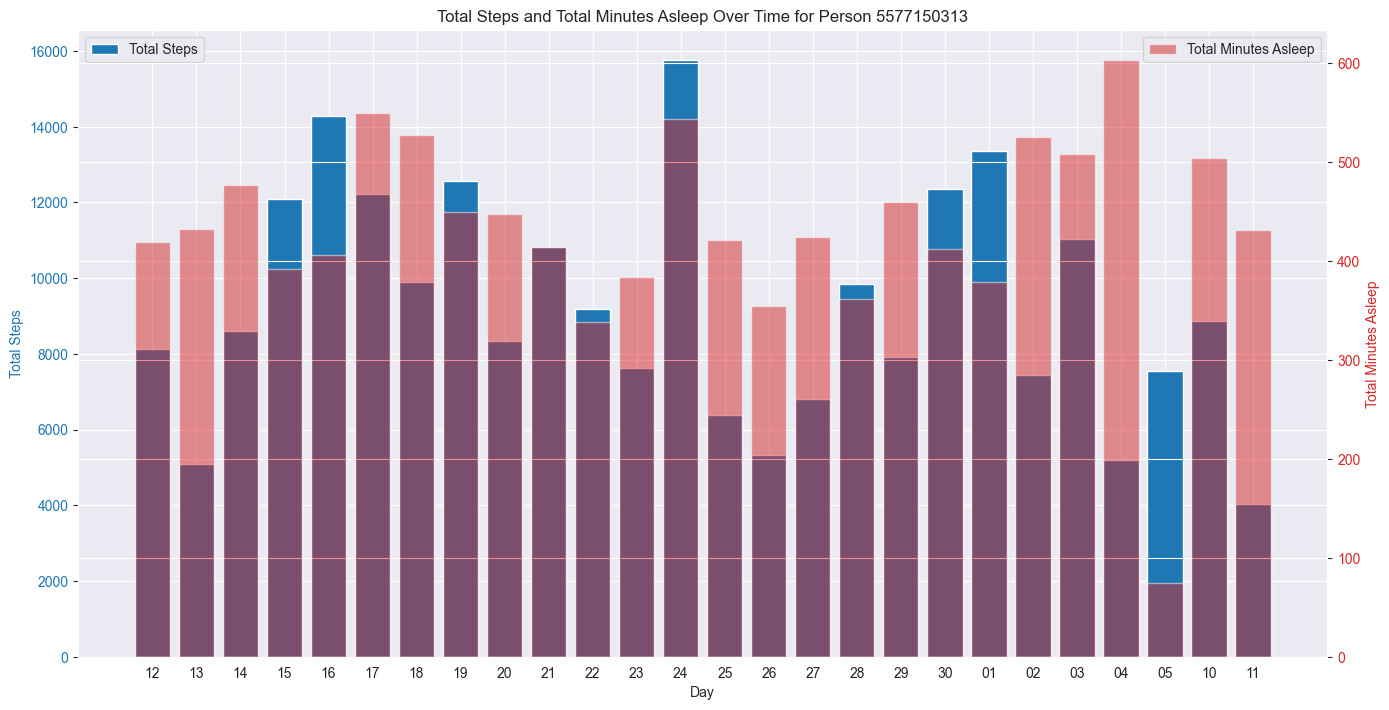

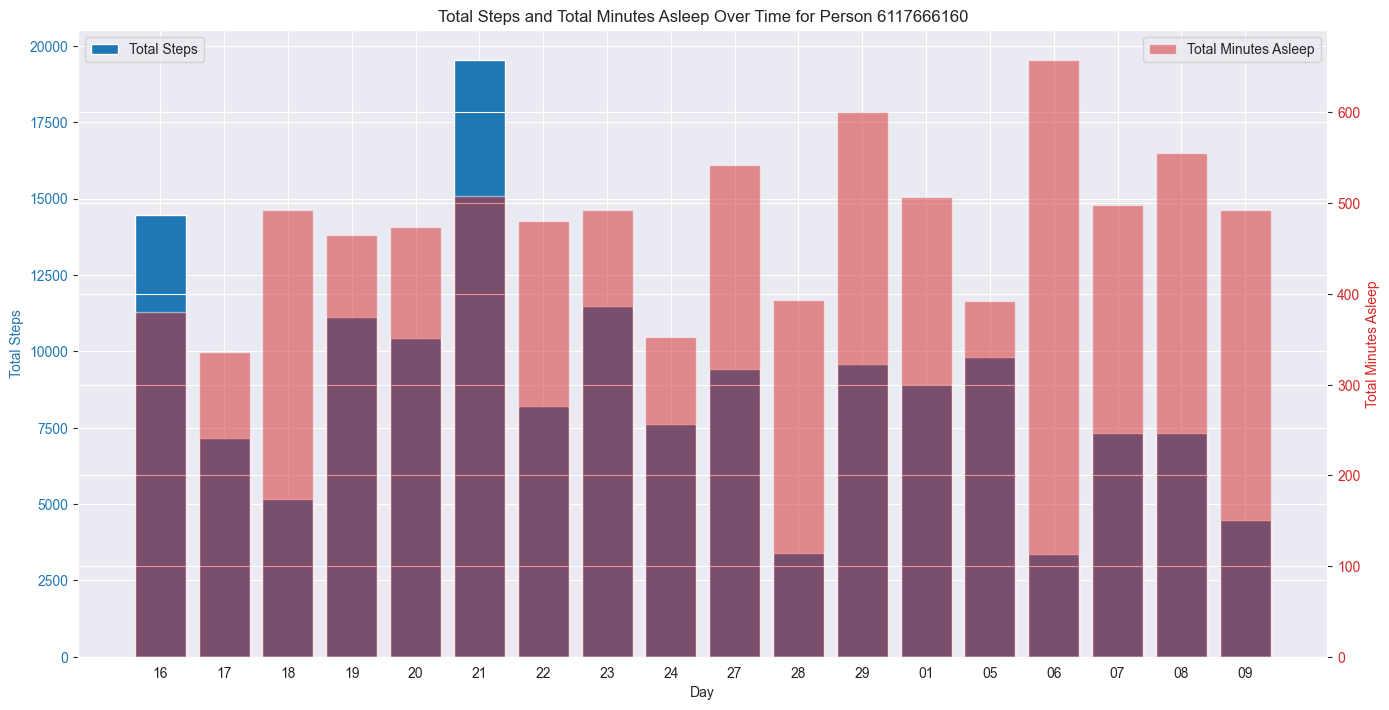

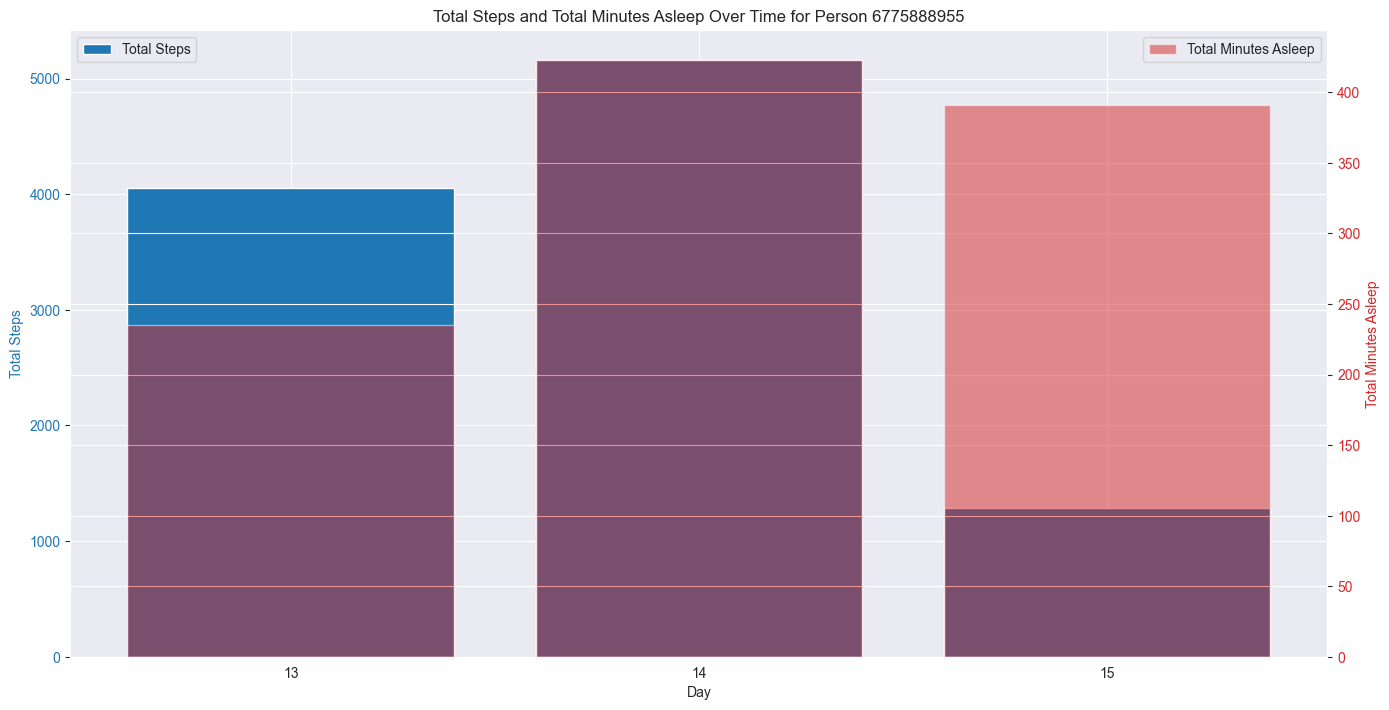

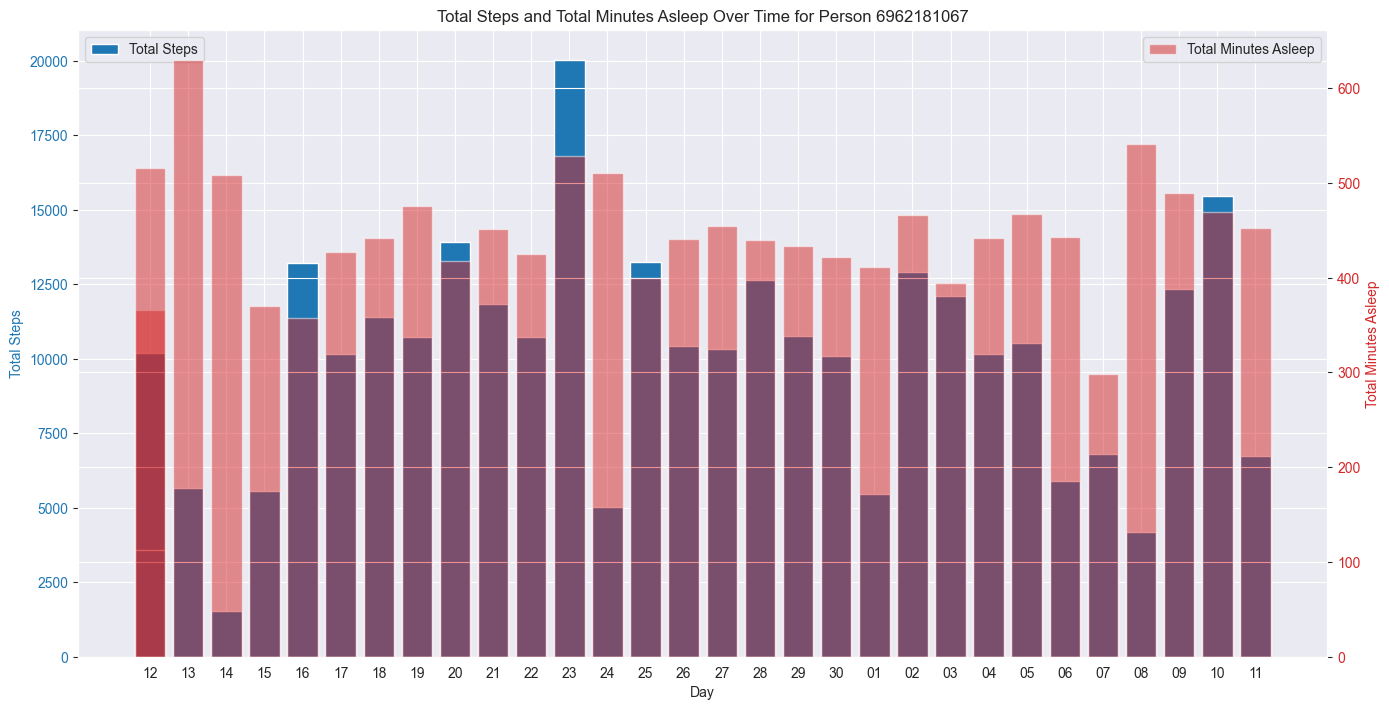

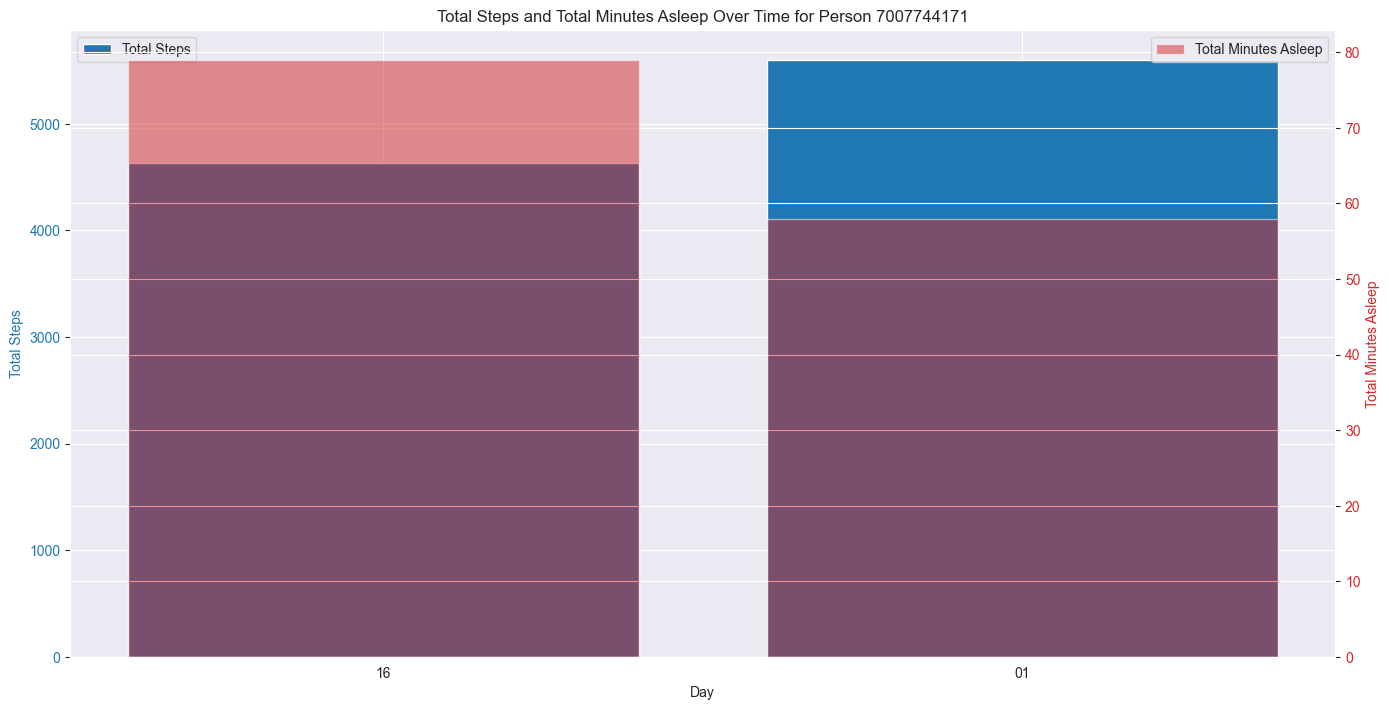

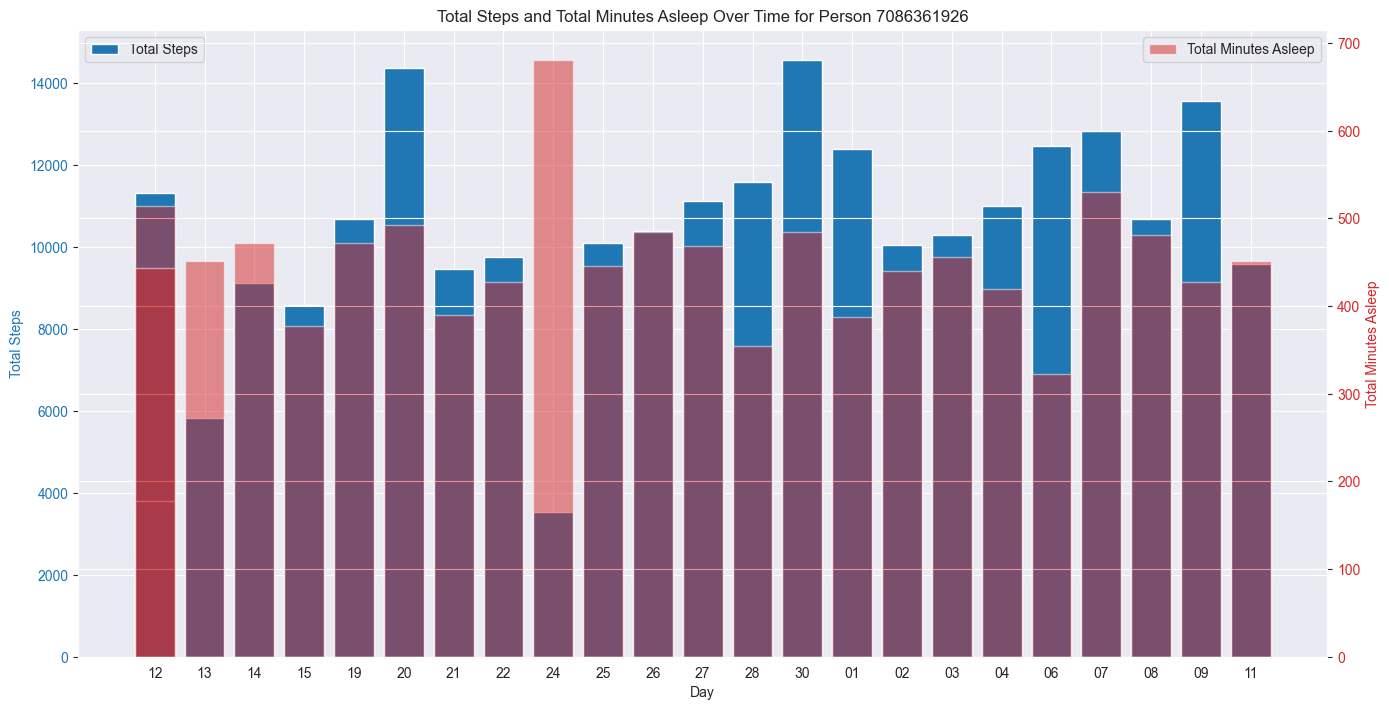

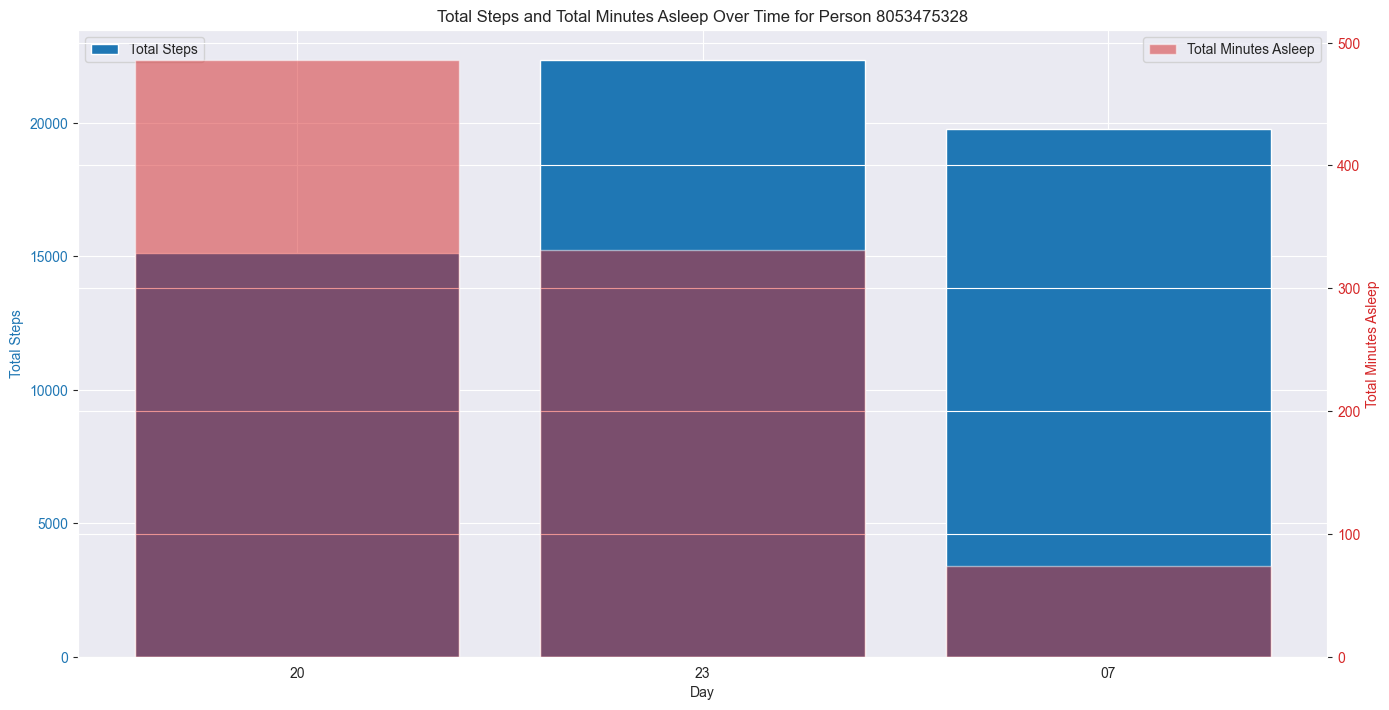

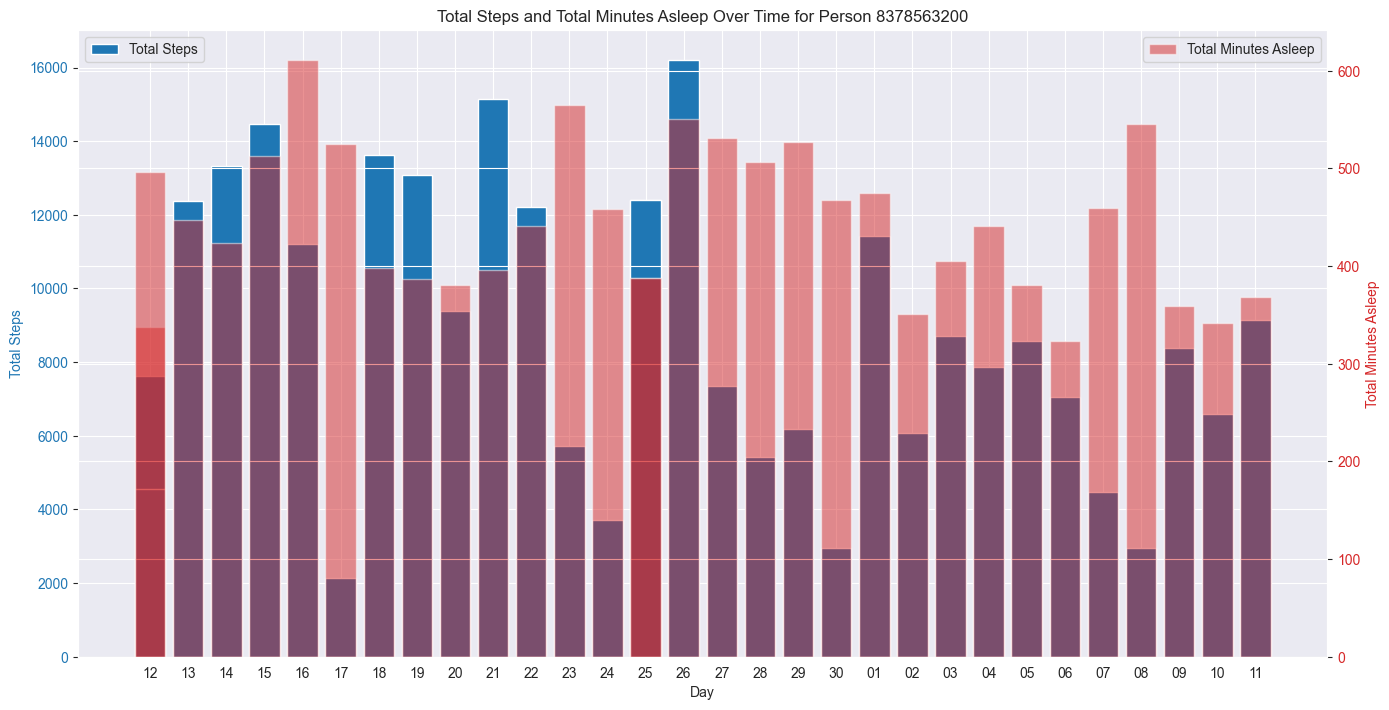

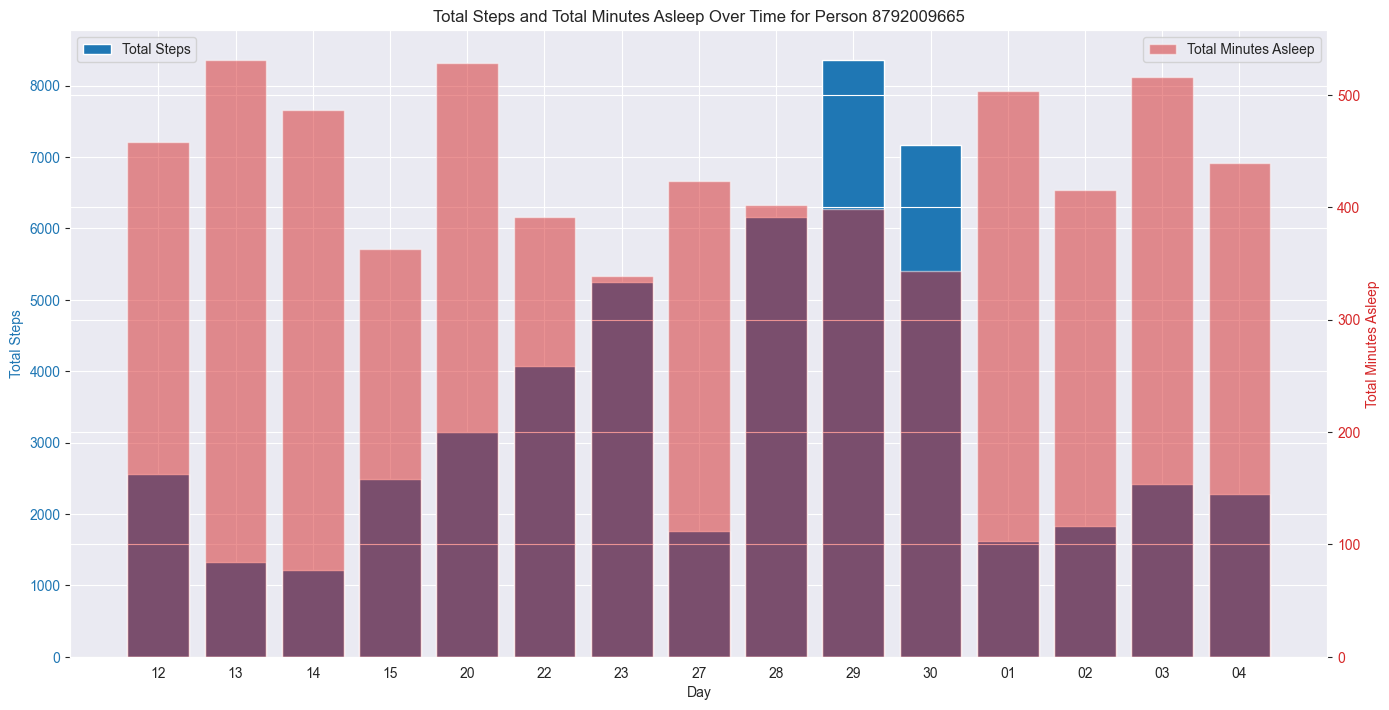

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lataa data
daily_activity = pd.read_csv('archive/dailyActivity_merged.csv')
sleep_data = pd.read_csv('archive/sleepDay_merged.csv')

# Muunna 'ActivityDate' ja 'SleepDay' sarakkeet datetime-muotoon
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
sleep_data['SleepDay'] = pd.to_datetime(sleep_data['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

# Yhdistä datasetit 'Id' ja päivämäärä sarakkeiden perusteella
merged_data = pd.merge(daily_activity, sleep_data, left_on=['Id', 'ActivityDate'], right_on=['Id', 'SleepDay'], how='inner')

# Poista tarpeettomat sarakkeet
merged_data = merged_data[['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TotalMinutesAsleep', 'TotalTimeInBed']]

# Erota päivä ja kuukausi 'ActivityDate' sarakkeesta
merged_data['Day'] = merged_data['ActivityDate'].dt.strftime('%d')

# Hanki uniikit käyttäjä-ID:t
user_ids = merged_data['Id'].unique()

# Käy läpi jokainen käyttäjä ja luo kaavio
for user_id in user_ids:
    person_data = merged_data[merged_data['Id'] == user_id]

    # Piirtäminen
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Pylväskaavio Total Steps
    ax1.bar(person_data['Day'], person_data['TotalSteps'], color='tab:blue', label='Total Steps')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Total Steps', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.legend(loc='upper left')

    # Pylväskaavio Total Minutes Asleep
    ax2 = ax1.twinx()  # luo toinen akseli, joka jakaa saman x-akselin
    ax2.bar(person_data['Day'], person_data['TotalMinutesAsleep'], color='tab:red', alpha=0.5, label='Total Minutes Asleep')
    ax2.set_ylabel('Total Minutes Asleep', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')

    fig.tight_layout()  # muuten oikea y-merkintä on hieman leikattu
    plt.title(f'Total Steps and Total Minutes Asleep Over Time for Person {user_id}')
    plt.xticks(rotation=45)
    plt.show()

In [4]:
import pandas as pd

# Tiedostopolut
daily_activity = "archive/dailyActivity_merged.csv"
sleep_data = "archive/sleepDay_merged.csv"

# Ladataan datasetit
daily_activity = pd.read_csv(daily_activity)
sleep_data = pd.read_csv(sleep_data)

# Näytetään ensimmäiset rivit datasta
daily_activity.head(), sleep_data.head()


(           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
 0  1503960366    4/12/2016       13162           8.50             8.50   
 1  1503960366    4/13/2016       10735           6.97             6.97   
 2  1503960366    4/14/2016       10460           6.74             6.74   
 3  1503960366    4/15/2016        9762           6.28             6.28   
 4  1503960366    4/16/2016       12669           8.16             8.16   
 
    LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
 0                       0.0                1.88                      0.55   
 1                       0.0                1.57                      0.69   
 2                       0.0                2.44                      0.40   
 3                       0.0                2.14                      1.26   
 4                       0.0                2.71                      0.41   
 
    LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
 0     

In [5]:
# Muutetaan päivämääräkentät yhtenäiseen muotoon
daily_activity["ActivityDate"] = pd.to_datetime(daily_activity["ActivityDate"], format="%m/%d/%Y")
sleep_data["SleepDay"] = pd.to_datetime(sleep_data["SleepDay"], format="%m/%d/%Y")

# Yhdistetään data 'Id' ja päivämäärän perusteella
merged_df = pd.merge(daily_activity, sleep_data, left_on=["Id", "ActivityDate"], right_on=["Id", "SleepDay"], how="inner")

# Lasketaan unen tehokkuus
merged_df["SleepInefficiency"] = merged_df["TotalTimeInBed"] - merged_df["TotalMinutesAsleep"]

# Valitaan vain tarvittavat sarakkeet
final_df = merged_df[["Id", "ActivityDate", "SleepInefficiency", "VeryActiveDistance"]]

# Tarkistetaan puuttuvat arvot ja datasetin koko
final_df.info(), final_df.head()


ValueError: unconverted data remains when parsing with format "%m/%d/%Y": " 12:00:00 AM", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Oletetaan, että final_df on jo määritelty ja sisältää tarvittavat sarakkeet
# Tarkista, että vaaditut sarakkeet ovat DataFramessa
required_columns = ["SleepInefficiency", "VeryActiveDistance"]
if all(column in final_df.columns for column in required_columns):
    # Käsittele mahdolliset puuttuvat arvot
    final_df.loc[:, required_columns] = final_df[required_columns].fillna(0)

    # Normalisointi (Min-Max skaalaus)
    minmax_scaler = MinMaxScaler()
    final_df.loc[:, ["SleepInefficiency_Norm", "VeryActiveDistance_Norm"]] = minmax_scaler.fit_transform(
        final_df[["SleepInefficiency", "VeryActiveDistance"]])

    # Standardisointi (Z-skaalaus)
    standard_scaler = StandardScaler()
    final_df.loc[:, ["SleepInefficiency_Std", "VeryActiveDistance_Std"]] = standard_scaler.fit_transform(
        final_df[["SleepInefficiency", "VeryActiveDistance"]])

    # Näytä normalisoidut ja standardisoidut arvot
    print(final_df.head())
else:
    print("Vaaditut sarakkeet puuttuvat DataFramesta.")

           Id ActivityDate  SleepInefficiency  VeryActiveDistance  \
0  1503960366   2016-04-12                 19                1.88   
1  1503960366   2016-04-13                 23                1.57   
2  1503960366   2016-04-15                 30                2.14   
3  1503960366   2016-04-16                 27                2.71   
4  1503960366   2016-04-17                 12                3.19   

   SleepInefficiency_Norm  VeryActiveDistance_Norm  SleepInefficiency_Std  \
0                0.051213                 0.149920              -0.433677   
1                0.061995                 0.125199              -0.347681   
2                0.080863                 0.170654              -0.197187   
3                0.072776                 0.216108              -0.261685   
4                0.032345                 0.254386              -0.584170   

   VeryActiveDistance_Std  
0                0.215688  
1                0.060061  
2                0.346214  
3         

In [7]:
from sklearn.linear_model import LinearRegression

# Määritetään muuttujat
X = final_df[["SleepInefficiency_Std"]]  # Selittävä muuttuja (unen tehottomuus)
y = final_df["VeryActiveDistance_Std"]  # Selitettävä muuttuja (aktiivinen liikunta)

# Luodaan ja sovitetaan lineaarinen regressiomalli
model = LinearRegression()
model.fit(X, y)

# Mallin kertoimet ja selitysaste
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"Regression coefficient: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_squared}")


Regression coefficient: -0.04152121283866114
Intercept: 8.316472867192887e-17
R-squared: 0.0017240111155933935


### 4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

### 5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

### 6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.